# Cricket Player Count Pipeline
## Two-Stage ML: Cell-Level Classification → Image-Level Regression

> **No deep learning.** Handcrafted features only (HSV/RGB histograms, texture, edge, HOG).
> **Model 1** — cell-level binary classifier (`player_present`)
> **Model 2** — image-level count regressor (`count`)

## Section 1 · Imports & Configuration

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import warnings
import joblib
import copy
from collections import defaultdict

from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    GradientBoostingClassifier, RandomForestRegressor,
    ExtraTreesRegressor, GradientBoostingRegressor,
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error,
)
from scipy.stats import skew as scipy_skew
from skimage.measure import label as sk_label, regionprops

try:
    import cv2
    CV2_AVAILABLE = True
except ImportError:
    CV2_AVAILABLE = False
    print("OpenCV not available — Section 12 image demo limited")

try:
    from huggingface_hub import snapshot_download
    HF_AVAILABLE = True
except ImportError:
    HF_AVAILABLE = False
    print("huggingface_hub not available — Section 12 image demo skipped")

warnings.filterwarnings("ignore")

# ─── Config ────────────────────────────────────────────────────────────────────
DATA_PATH    = "Dataset_Features_Combined_Final.csv"
IMAGE_DIR    = None   # resolved in Section 12
RANDOM_STATE = 42
FOLDS        = [1, 2, 3, 4]

# ─── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({"figure.dpi": 100, "font.size": 10, "axes.titlesize": 11})
sns.set_theme(style="whitegrid", palette="Set2")
CMAP    = "YlOrRd"
PALETTE = sns.color_palette("Set2")
print("All imports loaded successfully")

All imports loaded successfully


## Section 2 · Load & Validate Data

In [62]:
REQUIRED_COLS = [
    "Image File Name", "cell_row", "cell_col", "cell_id",
    "f_center_x", "f_center_y", "fold_id", "label", "player_present", "count",
]

def load_data(path):
    return pd.read_csv(path)

def validate_final_csv(df):
    issues = []
    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing:
        issues.append(f"Missing columns: {missing}")
    if "player_present" in df.columns:
        uvals = set(df["player_present"].dropna().unique())
        if not uvals.issubset({0, 1}):
            issues.append(f"player_present has unexpected values: {uvals}")
    if "Image File Name" in df.columns:
        cc = df.groupby("Image File Name").size()
        non64 = cc[cc != 64]
        if len(non64):
            issues.append(f"{len(non64)} images do not have exactly 64 cells")
    if {"fold_id", "Image File Name"}.issubset(df.columns):
        chk = df.groupby("Image File Name")["fold_id"].nunique()
        bad = chk[chk > 1]
        if len(bad):
            issues.append(f"{len(bad)} images have multiple fold_ids")
    if {"count", "Image File Name"}.issubset(df.columns):
        chk = df.groupby("Image File Name")["count"].nunique()
        bad = chk[chk > 1]
        if len(bad):
            issues.append(f"{len(bad)} images have inconsistent count values")
    if issues:
        print("Validation issues:")
        for i in issues:
            print(f"  - {i}")
    else:
        print("✓ All validation checks passed")
    return issues

Shape        : (64832, 272)
Unique images: 1013

Images per fold:
         images
fold_id        
1           250
2           250
3           250
4           263

✓ All validation checks passed

Min / Max / Range:


,min,max,range
cell_row,0.0000,7.0000,7.000
cell_col,0.0000,7.0000,7.000
cell_id,1.0000,64.0000,63.000
f_center_x,0.0625,0.9375,0.875
f_center_y,0.0625,0.9375,0.875
fold_id,1.0000,4.0000,3.000
label,0.0000,10.0000,10.000
player_present,0.0000,1.0000,1.000
count,0.0000,16.0000,16.000



Missing: 0 columns | Duplicates: 0 rows


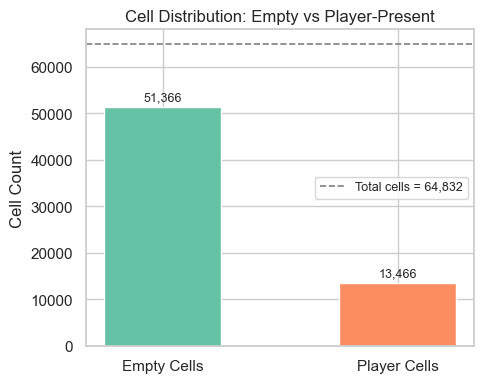


Feature encoding notes:
  f000-f191  : raw histogram counts    → HIGH skew, StandardScaler needed
  tex_00-25  : normalized [0,1]        → mild skew
  f_hog_*    : normalized HOG bins     → StandardScaler
  f_edge_*   : normalized edge stats   → StandardScaler
  f_center_* : already normalized      → no transform needed


In [63]:
df = load_data(DATA_PATH)
print(f"Shape        : {df.shape}")
print(f"Unique images: {df['Image File Name'].nunique()}")
print("\nImages per fold:")
print(df.groupby("fold_id")["Image File Name"].nunique().rename("images").to_frame().to_string())
print()
validate_final_csv(df)

# Min/Max/Range for metadata columns
meta = ["cell_row", "cell_col", "cell_id", "f_center_x", "f_center_y",
        "fold_id", "label", "player_present", "count"]
stats = df[meta].agg(["min", "max"]).T
stats["range"] = stats["max"] - stats["min"]
print("\nMin / Max / Range:")
display(stats)

# Missing & duplicates
miss = df.isnull().sum()
miss = miss[miss > 0]
print(f"\nMissing: {len(miss)} columns | Duplicates: {df.duplicated().sum()} rows")
if len(miss):
    display(miss.to_frame("missing_count").head(20))

# ─── Bar chart: empty vs player cells ─────────────────────────────────────────
total = len(df)
pp0   = int((df["player_present"] == 0).sum())
pp1   = int((df["player_present"] == 1).sum())

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["Empty Cells", "Player Cells"], [pp0, pp1],
              color=[PALETTE[0], PALETTE[1]], edgecolor="white", width=0.5)
ax.axhline(total, color="gray", ls="--", lw=1.2, label=f"Total cells = {total:,}")
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + total * 0.012,
            f"{b.get_height():,}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Cell Count")
ax.set_title("Cell Distribution: Empty vs Player-Present")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print("\nFeature encoding notes:")
print("  f000-f191  : raw histogram counts    → HIGH skew, StandardScaler needed")
print("  tex_00-25  : normalized [0,1]        → mild skew")
print("  f_hog_*    : normalized HOG bins     → StandardScaler")
print("  f_edge_*   : normalized edge stats   → StandardScaler")
print("  f_center_* : already normalized      → no transform needed")

## Section 3 · Engineered Fields Explained

| Field | Meaning |
|---|---|
| **player_present** | Binary version of `label`. `label=0` → no player (0). `label>0` → player present (1). Used as M1 target — no team needed, just player/background. |
| **f_center_x / f_center_y** | Normalized cell-center coordinates (0–1). Tell the model where the cell sits in the image. Players are not equally likely in all regions. |
| **fold_id** | Controls cross-validation split. All 64 cells of the same image share one fold_id. This prevents data leakage — cells from one image cannot appear in both train and validation. |

**One-hot row/col** (added in Section 5): 16 binary columns encode which row and column a cell occupies. Preferred over binary encoding to avoid artificial numeric ordering.

## Section 4 · Overall Modeling Plan

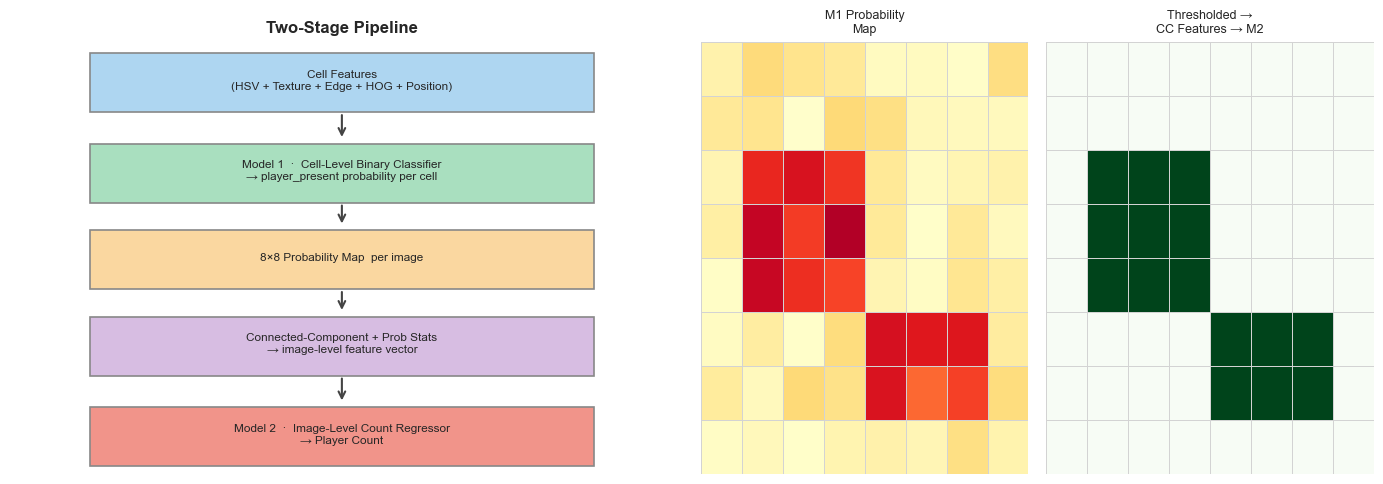

M1 answers : 'Which cells look player-like?'
Features   : 'How much player area? How is it grouped?'
M2 answers : 'How many players are in the image?'


In [64]:
fig = plt.figure(figsize=(14, 5))

# ── Left: flow diagram ────────────────────────────────────────────────────────
ax1 = fig.add_subplot(1, 2, 1)
ax1.set_xlim(0, 10); ax1.set_ylim(-0.5, 10.5); ax1.axis("off")
ax1.set_title("Two-Stage Pipeline", fontweight="bold")

boxes = [
    (5, 9.5, "Cell Features\n(HSV + Texture + Edge + HOG + Position)", "#AED6F1"),
    (5, 7.2, "Model 1  ·  Cell-Level Binary Classifier\n→ player_present probability per cell", "#A9DFBF"),
    (5, 5.0, "8×8 Probability Map  per image", "#FAD7A0"),
    (5, 2.8, "Connected-Component + Prob Stats\n→ image-level feature vector", "#D7BDE2"),
    (5, 0.5, "Model 2  ·  Image-Level Count Regressor\n→ Player Count", "#F1948A"),
]
for x, y, txt, col in boxes:
    ax1.add_patch(plt.Rectangle((x - 3.8, y - 0.8), 7.6, 1.5,
                                 facecolor=col, edgecolor="#888", lw=1.2, zorder=2))
    ax1.text(x, y, txt, ha="center", va="center", fontsize=8.5, zorder=3)

for y1, y2 in [(8.7, 8.0), (6.4, 5.8), (4.2, 3.6), (2.0, 1.3)]:
    ax1.annotate("", xy=(5, y2), xytext=(5, y1),
                 arrowprops=dict(arrowstyle="->", color="#444", lw=1.5))

# ── Right: fake 8×8 probability + thresholded binary ────────────────────────
ax2 = fig.add_subplot(1, 4, 3)
ax3 = fig.add_subplot(1, 4, 4)

np.random.seed(42)
fake_prob = np.random.rand(8, 8) * 0.25
fake_prob[2:5, 1:4] = np.random.uniform(0.65, 0.90, (3, 3))
fake_prob[5:7, 4:7] = np.random.uniform(0.55, 0.85, (2, 3))

sns.heatmap(fake_prob, ax=ax2, cmap=CMAP, vmin=0, vmax=1, cbar=False,
            linewidths=0.5, linecolor="lightgray")
ax2.set_title("M1 Probability\nMap", fontsize=9)
ax2.set_xticks([]); ax2.set_yticks([])

binary_map = (fake_prob > 0.5).astype(int)
sns.heatmap(binary_map, ax=ax3, cmap="Greens", vmin=0, vmax=1, cbar=False,
            linewidths=0.5, linecolor="lightgray")
ax3.set_title("Thresholded →\nCC Features → M2", fontsize=9)
ax3.set_xticks([]); ax3.set_yticks([])

plt.tight_layout(); plt.show()
print("M1 answers : 'Which cells look player-like?'")
print("Features   : 'How much player area? How is it grouped?'")
print("M2 answers : 'How many players are in the image?'")

## Section 5 · Feature Engineering: Row & Column One-Hot

One-hot preferred over binary encoding:
- Only 8 possible values per axis → adds just 16 columns total
- Binary encoding would create artificial numeric ordering (row 7 ≠ row 4 + row 3)
- All engineered feature names start with `f_`

In [65]:
def add_row_col_one_hot_features(df):
    row_dummies = pd.get_dummies(df["cell_row"], prefix="f_cell_row").astype(int)
    col_dummies = pd.get_dummies(df["cell_col"], prefix="f_cell_col").astype(int)
    for i in range(8):
        if f"f_cell_row_{i}" not in row_dummies.columns:
            row_dummies[f"f_cell_row_{i}"] = 0
        if f"f_cell_col_{i}" not in col_dummies.columns:
            col_dummies[f"f_cell_col_{i}"] = 0
    row_dummies = row_dummies[[f"f_cell_row_{i}" for i in range(8)]]
    col_dummies = col_dummies[[f"f_cell_col_{i}" for i in range(8)]]
    return pd.concat([df, row_dummies, col_dummies], axis=1)

df = add_row_col_one_hot_features(df)
new_cols = [c for c in df.columns if "f_cell_row_" in c or "f_cell_col_" in c]
print(f"Added {len(new_cols)} one-hot columns")
print(f"New df shape: {df.shape}")

Added 16 one-hot columns
New df shape: (64832, 288)


## Section 6 · Exploratory Data Analysis

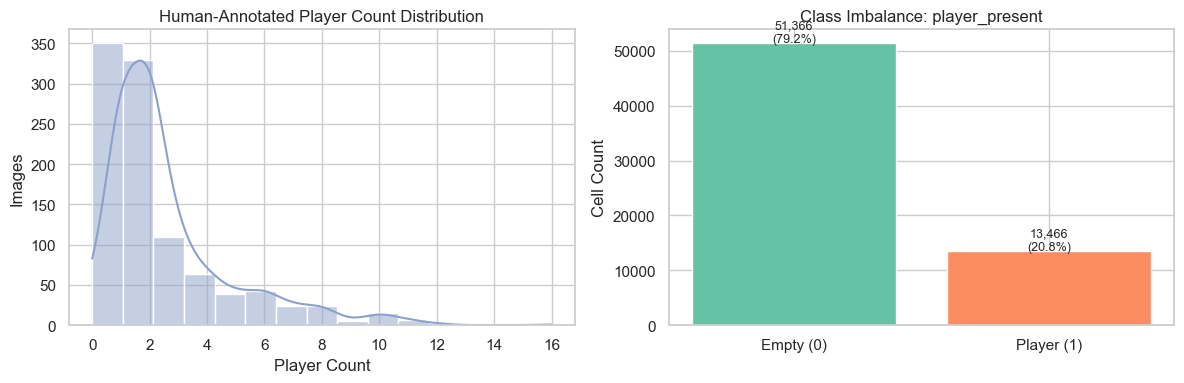

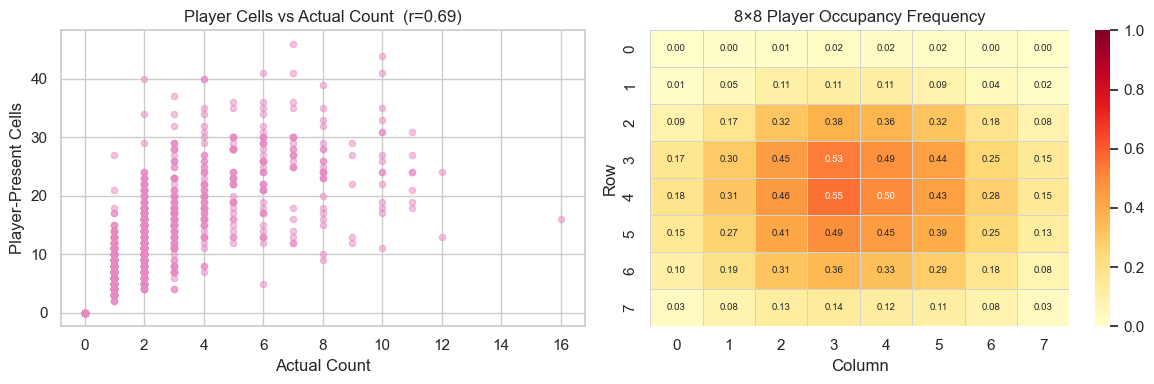

In [66]:
# Image-level aggregation
img_stats = df.groupby("Image File Name").agg(
    count=("count", "first"),
    fold_id=("fold_id", "first"),
    n_player_cells=("player_present", "sum"),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Count distribution
sns.histplot(img_stats["count"], ax=axes[0], kde=True, bins=15, color=PALETTE[2])
axes[0].set_title("Human-Annotated Player Count Distribution")
axes[0].set_xlabel("Player Count"); axes[0].set_ylabel("Images")

# Plot 2: Class imbalance
pp_counts = df["player_present"].value_counts()
axes[1].bar(["Empty (0)", "Player (1)"],
            [pp_counts.get(0, 0), pp_counts.get(1, 0)],
            color=[PALETTE[0], PALETTE[1]], edgecolor="white")
axes[1].set_title("Class Imbalance: player_present")
axes[1].set_ylabel("Cell Count")
total = len(df)
for i, v in enumerate([pp_counts.get(0, 0), pp_counts.get(1, 0)]):
    axes[1].text(i, v + total * 0.005, f"{v:,}\n({v/total*100:.1f}%)",
                 ha="center", fontsize=9)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 3: Player cells vs actual count
corr = img_stats["count"].corr(img_stats["n_player_cells"])
axes[0].scatter(img_stats["count"], img_stats["n_player_cells"],
                alpha=0.5, color=PALETTE[3], s=20)
axes[0].set_xlabel("Actual Count"); axes[0].set_ylabel("Player-Present Cells")
axes[0].set_title(f"Player Cells vs Actual Count  (r={corr:.2f})")

# Plot 4: 8×8 occupancy heatmap
occ_map = df.groupby(["cell_row", "cell_col"])["player_present"].mean().unstack(fill_value=0)
sns.heatmap(occ_map, ax=axes[1], cmap=CMAP, vmin=0, vmax=1,
            linewidths=0.5, linecolor="lightgray", annot=True, fmt=".2f",
            annot_kws={"size": 7})
axes[1].set_title("8×8 Player Occupancy Frequency")
axes[1].set_xlabel("Column"); axes[1].set_ylabel("Row")
plt.tight_layout(); plt.show()

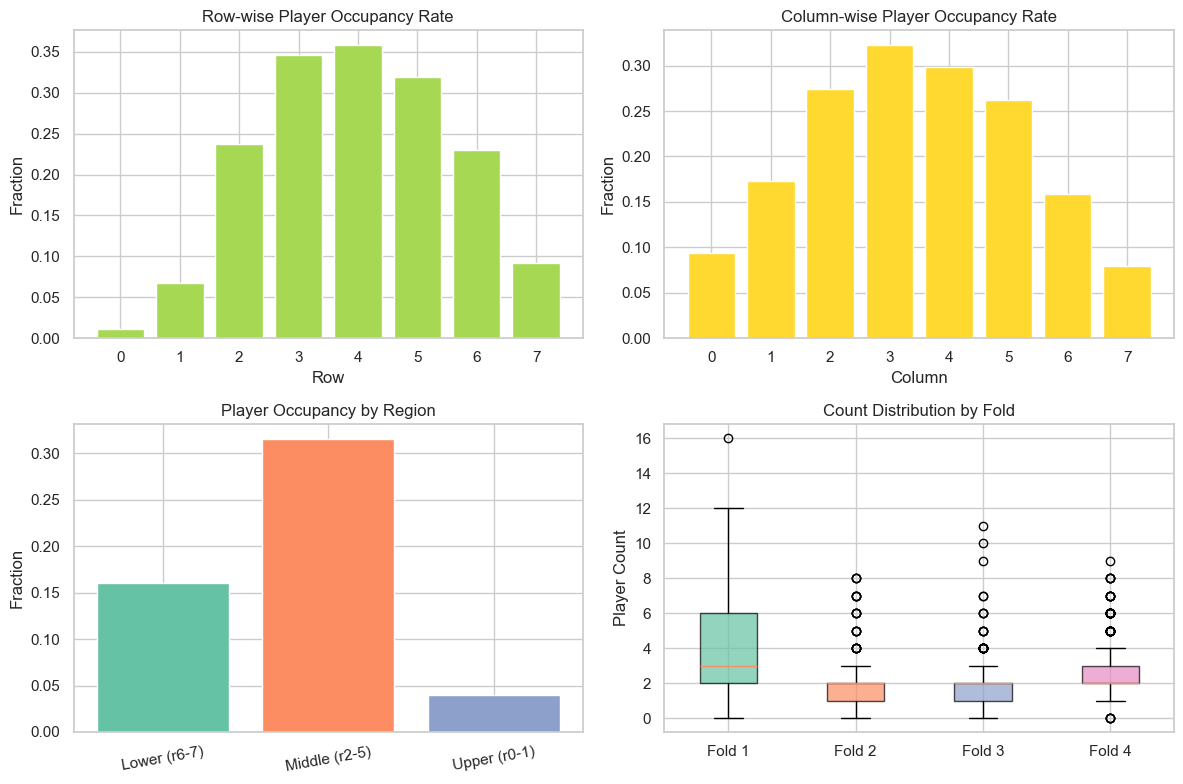

In [67]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot 5: Row-wise occupancy
row_occ = df.groupby("cell_row")["player_present"].mean()
axes[0, 0].bar(row_occ.index, row_occ.values, color=PALETTE[4], edgecolor="white")
axes[0, 0].set_title("Row-wise Player Occupancy Rate")
axes[0, 0].set_xlabel("Row"); axes[0, 0].set_ylabel("Fraction")

# Plot 6: Col-wise occupancy
col_occ = df.groupby("cell_col")["player_present"].mean()
axes[0, 1].bar(col_occ.index, col_occ.values, color=PALETTE[5], edgecolor="white")
axes[0, 1].set_title("Column-wise Player Occupancy Rate")
axes[0, 1].set_xlabel("Column"); axes[0, 1].set_ylabel("Fraction")

# Plot 7: Region comparison
df["_region"] = "Middle (r2-5)"
df.loc[df["cell_row"] <= 1, "_region"] = "Upper (r0-1)"
df.loc[df["cell_row"] >= 6, "_region"] = "Lower (r6-7)"
reg_occ = df.groupby("_region")["player_present"].mean().reset_index()
axes[1, 0].bar(reg_occ["_region"], reg_occ["player_present"],
               color=PALETTE[:3], edgecolor="white")
axes[1, 0].set_title("Player Occupancy by Region")
axes[1, 0].set_ylabel("Fraction")
axes[1, 0].tick_params(axis="x", rotation=10)

# Plot 8: Fold-wise count distribution
fold_data = [img_stats[img_stats["fold_id"] == f]["count"].values for f in FOLDS]
bp = axes[1, 1].boxplot(fold_data, labels=[f"Fold {f}" for f in FOLDS],
                         patch_artist=True)
for patch, col in zip(bp["boxes"], PALETTE):
    patch.set_facecolor(col); patch.set_alpha(0.7)
axes[1, 1].set_title("Count Distribution by Fold")
axes[1, 1].set_ylabel("Player Count")

plt.tight_layout(); plt.show()

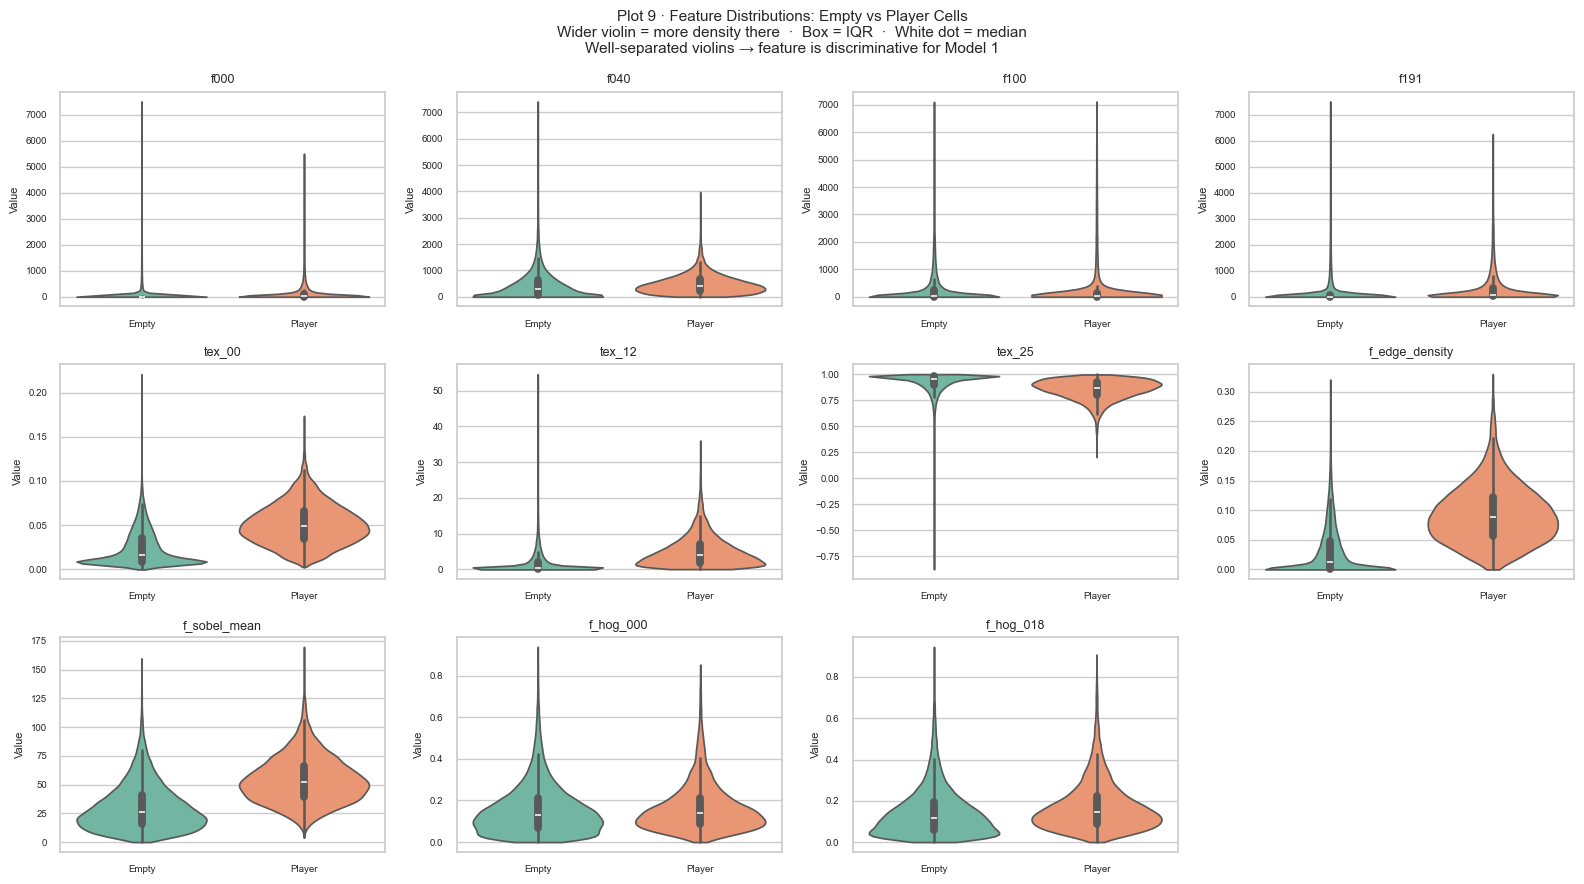

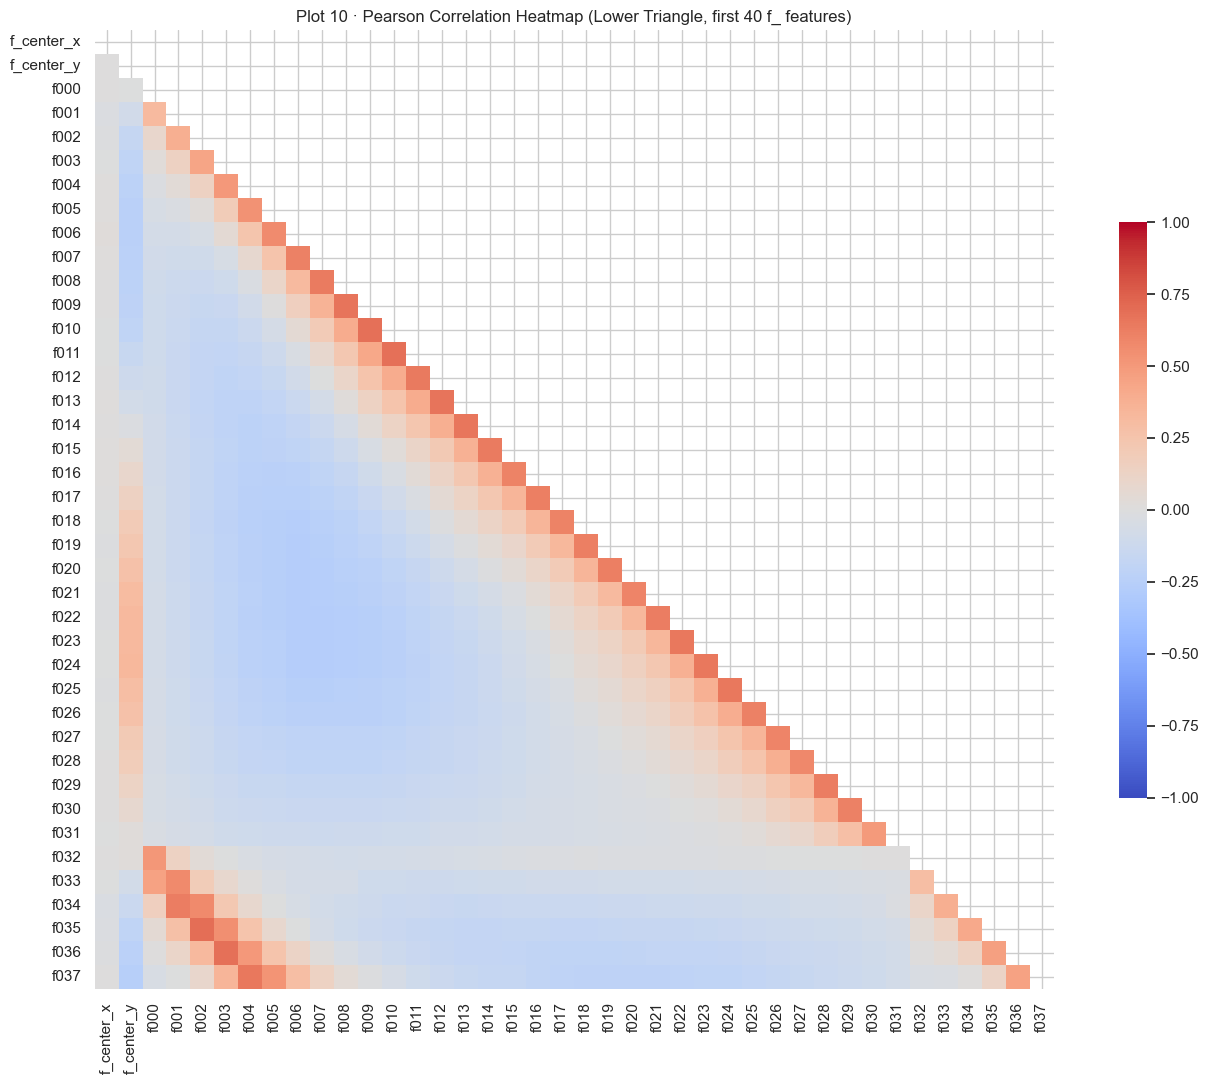

In [68]:
# Plot 9 — Feature Distributions: Empty vs Player Cells (violin plots)
#
# WHY REPLACED from original pair-grid:
#   The 11×11 lower-triangle scatter matrix was not useful because:
#   (a) scatter plots at alpha=0.04 across thousands of rows are unreadable at small size
#   (b) it shows NO class-discrimination information — does not answer:
#       "do these features actually separate player cells from empty cells?"
#
# REPLACEMENT — per-feature violin plots split by player_present (0=Empty, 1=Player):
#   • Shows distribution shape and spread for each class side-by-side
#   • Directly reveals which features are discriminative for Model 1
#   • Skewness is still visible from the violin width
#   • Far more actionable for pre-modelling analysis

sample_feats_v = (["f000", "f040", "f100", "f191"] +
                  ["tex_00", "tex_12", "tex_25"] +
                  ["f_edge_density", "f_sobel_mean", "f_hog_000", "f_hog_018"])
sample_feats_v = [c for c in sample_feats_v if c in df.columns]

long_df = df[sample_feats_v + ["player_present"]].melt(
    id_vars="player_present", var_name="feature", value_name="value"
)
long_df["Class"] = long_df["player_present"].map({0: "Empty", 1: "Player"})

fig, axes = plt.subplots(3, 4, figsize=(16, 9))
for i, feat in enumerate(sample_feats_v):
    ax = axes.flat[i]
    feat_sub = long_df[long_df["feature"] == feat]
    sns.violinplot(data=feat_sub, x="Class", y="value",
                   ax=ax, palette=[PALETTE[0], PALETTE[1]],
                   inner="box", cut=0)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("Value", fontsize=8)
    ax.tick_params(axis="both", labelsize=7)

for ax in list(axes.flat)[len(sample_feats_v):]:
    ax.axis("off")

fig.suptitle(
    "Plot 9 \u00b7 Feature Distributions: Empty vs Player Cells\n"
    "Wider violin = more density there  \u00b7  Box = IQR  \u00b7  White dot = median\n"
    "Well-separated violins \u2192 feature is discriminative for Model 1",
    fontsize=11
)
plt.tight_layout()
plt.show()

# Plot 10: Pearson correlation heatmap (lower triangle, first 40 f_ features)
all_f = [c for c in df.columns
         if c.startswith("f") and df[c].dtype in [np.float64, np.int64]
         and c not in {"fold_id", "player_present", "image_number"}]
corr_cols = all_f[:40]
corr_mat  = df[corr_cols].corr()
mask      = np.triu(np.ones_like(corr_mat, dtype=bool))
fig, ax   = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_mat, mask=mask, ax=ax, cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0,
            cbar_kws={"shrink": 0.6})
ax.set_title("Plot 10 \u00b7 Pearson Correlation Heatmap (Lower Triangle, first 40 f_ features)")
plt.tight_layout()
plt.show()

## Section 6 Part 2 · EDA Decision Summary

> *This part is speculation and planning. Final model comparison is decided by cross-validation metrics.*

In [69]:
feat_cols_eda = [c for c in df.columns
                 if c.startswith("f") or c.startswith("tex_")
                 if df[c].dtype in [np.float64, np.int64]
                 if c not in {"fold_id", "player_present", "image_number",
                               "label", "count"}]

skewness  = df[feat_cols_eda].apply(scipy_skew).rename("skewness")
ranges    = df[feat_cols_eda].agg(["min", "max"]).T
ranges["range"] = ranges["max"] - ranges["min"]
missing_c = df[feat_cols_eda].isnull().sum().rename("missing")
pp_ratio  = df["player_present"].value_counts(normalize=True)
count_desc = img_stats["count"].describe()

eda_summary = pd.DataFrame({
    "skewness": skewness,
    "missing" : missing_c,
    "min"     : ranges["min"],
    "max"     : ranges["max"],
    "range"   : ranges["range"],
})
highly_skewed = eda_summary[eda_summary["skewness"].abs() > 2]

print(f"Total feature columns   : {len(feat_cols_eda)}")
print(f"Highly skewed (|skew|>2): {len(highly_skewed)}")
print(f"player_present ratio    : {pp_ratio.to_dict()}")
print(f"Count — mean={count_desc['mean']:.1f}  std={count_desc['std']:.1f}  max={count_desc['max']:.0f}")
print("\nTop skewed features:")
display(highly_skewed.sort_values("skewness", ascending=False).head(10))

print("\n=== EDA-based Decisions ===")
print(f"1. Scaling required?      YES  — f000-f191 are raw counts with large range")
print(f"2. Log/PowerTransform?    YES  — {len(highly_skewed)} features have |skew|>2 (mainly histogram bins)")
print(f"3. PCA useful?            YES  — {len(feat_cols_eda)} input features; PCA reduces dimensionality")
print(f"4. Columns to exclude?    image_number, fold_id, label, Train Or Test, cell_row, cell_col")
print(f"5. Class imbalance?       YES  — use class_weight='balanced' for LR/RF/ET; sample_weight for GBM")

Total feature columns   : 278
Highly skewed (|skew|>2): 234
player_present ratio    : {0: 0.7922939289239882, 1: 0.20770607107601186}
Count — mean=2.6  std=2.2  max=16

Top skewed features:


,skewness,missing,min,max,range
f160,24.027714,0,0.0,7500.0,7500.0
f108,22.043224,0,0.0,5787.0,5787.0
f157,20.800204,0,0.0,7347.0,7347.0
f106,17.982930,0,0.0,5881.0,5881.0
f063,17.959620,0,0.0,7500.0,7500.0
f107,15.479554,0,0.0,6274.0,6274.0
f109,13.218824,0,0.0,6415.0,6415.0
f161,13.067057,0,0.0,7484.0,7484.0
f123,12.067673,0,0.0,5390.0,5390.0
f062,11.673465,0,0.0,6789.0,6789.0



=== EDA-based Decisions ===
1. Scaling required?      YES  — f000-f191 are raw counts with large range
2. Log/PowerTransform?    YES  — 234 features have |skew|>2 (mainly histogram bins)
3. PCA useful?            YES  — 278 input features; PCA reduces dimensionality
4. Columns to exclude?    image_number, fold_id, label, Train Or Test, cell_row, cell_col
5. Class imbalance?       YES  — use class_weight='balanced' for LR/RF/ET; sample_weight for GBM


## Section 7 · Preprocessing & Imbalance Handling for Model 1

Cell feature columns: 278
  f000-f191 hist : 192
  tex_*          : 26
  edge/hog/sobel : 42
  row/col onehot : 16
  center_x/y     : 2


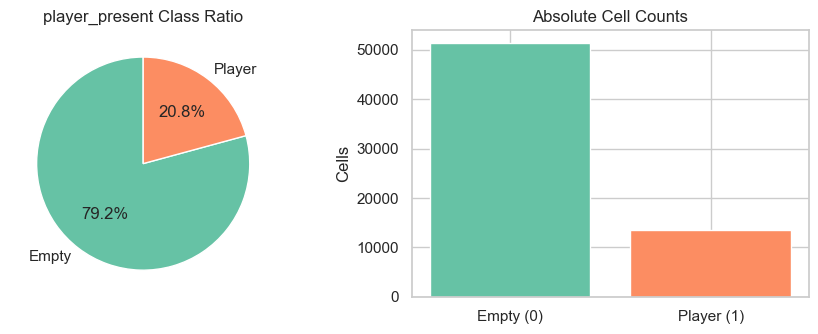

Imbalance ratio (minority/majority): 0.262
Strategy: class_weight='balanced' for LR/RF/ET; sample_weight for GBM
Threshold sweep: [0.30, 0.40, 0.50, 0.60, 0.70] — pick on val F1

=== EDA Recommendations → Actions Taken ===
✓ [S7] Scaling         : StandardScaler in every M1 pipeline step (f000-f191 large-range counts)
✓ [S7] Column exclusion: image_number / fold_id / label / Train Or Test / cell_row/col excluded
✓ [S7] Class imbalance : class_weight='balanced' for LR / RF / ET;  sample_weight for GBM
✓ [S9] PCA             : Will test No PCA / 90% / 95% / 98% variance — see Section 9
✓ [S9] Threshold tuning: Will sweep [0.30, 0.40, 0.50, 0.60, 0.70] on OOF F1 — see Section 9
~ [skipped] PowerTransformer: imported but not applied — StandardScaler + tree models handle skewed histogram counts adequately


In [70]:
EXCLUDE_FROM_FEATURES = {
    "Image File Name", "Train Or Test", "label", "player_present",
    "count", "fold_id", "image_number", "_region",
    "cell_row", "cell_col", "cell_id",
}

def get_cell_feature_columns(df):
    out = []
    for c in df.columns:
        if c in EXCLUDE_FROM_FEATURES:
            continue
        if (c.startswith("f") or c.startswith("tex_")):
            if df[c].dtype in [np.float64, np.int64, float, int]:
                out.append(c)
    return out

CELL_FEAT_COLS = get_cell_feature_columns(df)
print(f"Cell feature columns: {len(CELL_FEAT_COLS)}")
print(f"  f000-f191 hist : {sum(1 for c in CELL_FEAT_COLS if c[:4].startswith('f0') or c[:4].startswith('f1'))}")
print(f"  tex_*          : {sum(1 for c in CELL_FEAT_COLS if c.startswith('tex'))}")
print(f"  edge/hog/sobel : {sum(1 for c in CELL_FEAT_COLS if any(k in c for k in ['hog','edge','canny','sobel','laplacian','contour']))}")
print(f"  row/col onehot : {sum(1 for c in CELL_FEAT_COLS if 'cell_row_' in c or 'cell_col_' in c)}")
print(f"  center_x/y     : {sum(1 for c in CELL_FEAT_COLS if 'center' in c)}")

def make_model1_pipeline(model, use_pca=False, pca_var=0.95):
    steps = [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ]
    if use_pca:
        steps.append(("pca", PCA(n_components=pca_var, svd_solver="full",
                                  random_state=RANDOM_STATE)))
    steps.append(("clf", model))
    return Pipeline(steps)

# Class imbalance visual
pp_counts = df["player_present"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].pie(pp_counts.values, labels=["Empty", "Player"],
             autopct="%1.1f%%", colors=[PALETTE[0], PALETTE[1]], startangle=90)
axes[0].set_title("player_present Class Ratio")
axes[1].bar(["Empty (0)", "Player (1)"], pp_counts.values,
             color=[PALETTE[0], PALETTE[1]], edgecolor="white")
axes[1].set_title("Absolute Cell Counts"); axes[1].set_ylabel("Cells")
plt.tight_layout(); plt.show()

imb = pp_counts.min() / pp_counts.max()
print(f"Imbalance ratio (minority/majority): {imb:.3f}")
print("Strategy: class_weight='balanced' for LR/RF/ET; sample_weight for GBM")
print("Threshold sweep: [0.30, 0.40, 0.50, 0.60, 0.70] — pick on val F1")

print("\n=== EDA Recommendations \u2192 Actions Taken ===")
print("\u2713 [S7] Scaling         : StandardScaler in every M1 pipeline step (f000-f191 large-range counts)")
print("\u2713 [S7] Column exclusion: image_number / fold_id / label / Train Or Test / cell_row/col excluded")
print("\u2713 [S7] Class imbalance : class_weight='balanced' for LR / RF / ET;  sample_weight for GBM")
print("\u2713 [S9] PCA             : Will test No PCA / 90\u0025 / 95\u0025 / 98\u0025 variance \u2014 see Section 9")
print("\u2713 [S9] Threshold tuning: Will sweep [0.30, 0.40, 0.50, 0.60, 0.70] on OOF F1 \u2014 see Section 9")
print("~ [skipped] PowerTransformer: imported but not applied \u2014 StandardScaler + tree models handle skewed histogram counts adequately")

## Section 8 · Cross-Validation Implementation

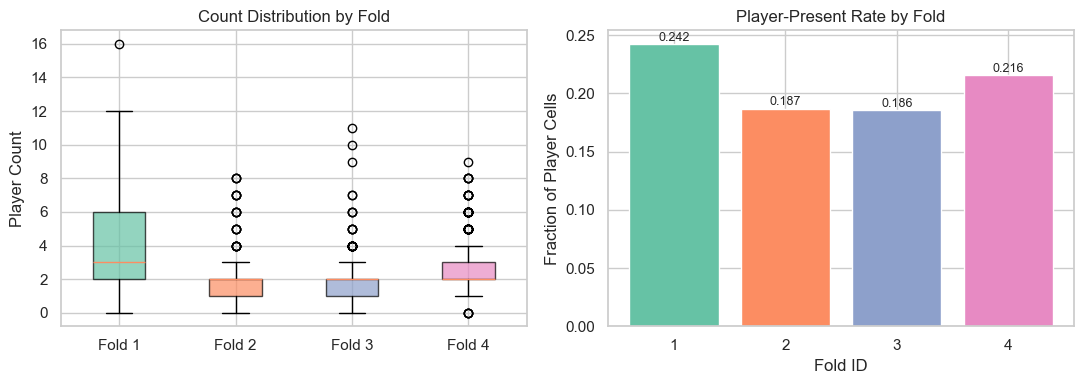

Folds appear balanced — safe for cross-validation


In [71]:
def get_train_valid_by_fold(df, fold_id):
    """Image-level split — all 64 cells of one image stay together."""
    val_mask = df["fold_id"] == fold_id
    return df[~val_mask].copy(), df[val_mask].copy()

def evaluate_binary_classifier(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    has_both = len(np.unique(y_true)) > 1
    return {
        "threshold": threshold,
        "accuracy" : float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall"   : float(recall_score(y_true, y_pred, zero_division=0)),
        "f1"       : float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc"  : float(roc_auc_score(y_true, y_prob)) if has_both else 0.5,
        "pr_auc"   : float(average_precision_score(y_true, y_prob)) if has_both else 0.5,
        "cm"       : confusion_matrix(y_true, y_pred),
    }

def evaluate_count_predictions(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "mae"       : float(mean_absolute_error(y_true, y_pred)),
        "rmse"      : float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "exact_acc" : float(np.mean(y_true == y_pred)),
        "pm1_acc"   : float(np.mean(np.abs(y_true - y_pred) <= 1)),
    }

# Fold validation plots
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

fold_data = [img_stats[img_stats["fold_id"] == f]["count"].values for f in FOLDS]
bp = axes[0].boxplot(fold_data, labels=[f"Fold {f}" for f in FOLDS], patch_artist=True)
for patch, col in zip(bp["boxes"], PALETTE):
    patch.set_facecolor(col); patch.set_alpha(0.7)
axes[0].set_title("Count Distribution by Fold"); axes[0].set_ylabel("Player Count")

pp_rate = df.groupby("fold_id")["player_present"].mean()
axes[1].bar([str(f) for f in pp_rate.index], pp_rate.values,
             color=PALETTE, edgecolor="white")
axes[1].set_title("Player-Present Rate by Fold")
axes[1].set_xlabel("Fold ID"); axes[1].set_ylabel("Fraction of Player Cells")
for i, v in enumerate(pp_rate.values):
    axes[1].text(i, v + 0.003, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()
print("Folds appear balanced — safe for cross-validation")

## Section 9 · Model 1: Cell-Level Player-Presence Classifier

In [72]:
def train_model1_crossval(df, model, feature_cols, use_pca=False, pca_var=0.95):
    df = df.reset_index(drop=True)
    oof_probs    = np.zeros(len(df))
    fold_metrics = []

    for fold in FOLDS:
        train_df, val_df = get_train_valid_by_fold(df, fold)
        train_df = train_df.reset_index(drop=True)
        val_df   = val_df.reset_index(drop=True)

        X_tr = train_df[feature_cols].values
        y_tr = train_df["player_present"].values
        X_val = val_df[feature_cols].values
        y_val = val_df["player_present"].values

        pipe = make_model1_pipeline(copy.deepcopy(model), use_pca=use_pca, pca_var=pca_var)

        # Handle GBM sample weights (no class_weight param)
        clf = pipe.named_steps["clf"]
        if hasattr(clf, "class_weight") and clf.class_weight == "balanced":
            pipe.fit(X_tr, y_tr)
        else:
            n  = len(y_tr)
            n0 = (y_tr == 0).sum(); n1 = (y_tr == 1).sum()
            w0 = n / (2 * max(n0, 1)); w1 = n / (2 * max(n1, 1))
            sw = np.where(y_tr == 0, w0, w1)
            try:
                pipe.fit(X_tr, y_tr, clf__sample_weight=sw)
            except Exception:
                pipe.fit(X_tr, y_tr)

        probs = pipe.predict_proba(X_val)[:, 1]

        # Write OOF probabilities back to original df positions
        orig_idx = df[df["fold_id"] == fold].index
        oof_probs[orig_idx] = probs

        n_pca = None
        if use_pca and "pca" in pipe.named_steps:
            n_pca = int(pipe.named_steps["pca"].n_components_)

        m = evaluate_binary_classifier(y_val, probs)
        m.update({"fold": fold, "n_pca_components": n_pca})
        fold_metrics.append(m)

    return pd.DataFrame(fold_metrics), oof_probs

In [73]:
print("=== Section 9: Executing EDA Action \u2014 PCA Variants ===")
print("Testing 4 PCA settings (No PCA / 90% / 95% / 98% variance) as decided in Section 6 Part 2")
print()
# Define classifiers
M1_MODELS = {
    "LogisticReg"  : LogisticRegression(class_weight="balanced", max_iter=500,
                                         random_state=RANDOM_STATE),
    "RandomForest" : RandomForestClassifier(n_estimators=150, class_weight="balanced",
                                             n_jobs=-1, random_state=RANDOM_STATE),
    "ExtraTrees"   : ExtraTreesClassifier(n_estimators=150, class_weight="balanced",
                                           n_jobs=-1, random_state=RANDOM_STATE),
    "GradientBoost": GradientBoostingClassifier(n_estimators=100,
                                                 random_state=RANDOM_STATE),
}

PCA_VARIANTS = {
    "No PCA"  : (False, 0.95),
    "PCA 90%" : (True,  0.90),
    "PCA 95%" : (True,  0.95),
    "PCA 98%" : (True,  0.98),
}

m1_results: dict = {}
m1_oof    : dict = {}

print("Training Model 1 experiments (be patient — ~16 experiments × 4 folds)...")
for mname, mobj in M1_MODELS.items():
    for pname, (use_pca, pca_var) in PCA_VARIANTS.items():
        key = (mname, pname)
        print(f"  {mname:15s} | {pname} ...", end=" ", flush=True)
        try:
            fold_df, oof = train_model1_crossval(
                df, copy.deepcopy(mobj), CELL_FEAT_COLS,
                use_pca=use_pca, pca_var=pca_var,
            )
            avg = fold_df[["accuracy","precision","recall","f1","roc_auc","pr_auc"]].mean()
            m1_results[key] = {"avg": avg, "folds": fold_df}
            m1_oof[key]     = oof
            print(f"F1={avg['f1']:.3f}  PR-AUC={avg['pr_auc']:.3f}")
        except Exception as e:
            print(f"ERROR: {e}")
            m1_results[key] = None; m1_oof[key] = None

print("Done.")

=== Section 9: Executing EDA Action — PCA Variants ===
Testing 4 PCA settings (No PCA / 90% / 95% / 98% variance) as decided in Section 6 Part 2

Training Model 1 experiments (be patient — ~16 experiments × 4 folds)...
  LogisticReg     | No PCA ... F1=0.734  PR-AUC=0.809
  LogisticReg     | PCA 90% ... F1=0.714  PR-AUC=0.791
  LogisticReg     | PCA 95% ... F1=0.717  PR-AUC=0.794
  LogisticReg     | PCA 98% ... F1=0.720  PR-AUC=0.797
  RandomForest    | No PCA ... F1=0.754  PR-AUC=0.822
  RandomForest    | PCA 90% ... F1=0.739  PR-AUC=0.803
  RandomForest    | PCA 95% ... F1=0.733  PR-AUC=0.800
  RandomForest    | PCA 98% ... F1=0.728  PR-AUC=0.797
  ExtraTrees      | No PCA ... F1=0.726  PR-AUC=0.834
  ExtraTrees      | PCA 90% ... F1=0.631  PR-AUC=0.815
  ExtraTrees      | PCA 95% ... F1=0.604  PR-AUC=0.811
  ExtraTrees      | PCA 98% ... F1=0.594  PR-AUC=0.806
  GradientBoost   | No PCA ... F1=0.728  PR-AUC=0.817
  GradientBoost   | PCA 90% ... F1=0.707  PR-AUC=0.794
  GradientBoost

Model 1 Results — Experiment Order (0–15, order they were run):


,Model,PCA,F1,Recall,Precision,ROC-AUC,PR-AUC,PCA Comps
Experiment,,,,,,,,
0,LogisticReg,No PCA,0.734,0.880,0.630,0.943,0.809,-
1,LogisticReg,PCA 90%,0.714,0.863,0.610,0.934,0.791,131
2,LogisticReg,PCA 95%,0.717,0.863,0.614,0.935,0.794,167
3,LogisticReg,PCA 98%,0.720,0.868,0.615,0.937,0.797,200
4,RandomForest,No PCA,0.754,0.802,0.713,0.948,0.822,-
5,RandomForest,PCA 90%,0.739,0.750,0.728,0.939,0.803,131
6,RandomForest,PCA 95%,0.733,0.732,0.734,0.938,0.800,167
7,RandomForest,PCA 98%,0.728,0.725,0.731,0.937,0.797,200
8,ExtraTrees,No PCA,0.726,0.655,0.815,0.950,0.834,-



Model 1 Results — Sorted by F1 Score (Best First):


,Model,PCA,F1,Recall,Precision,ROC-AUC,PR-AUC,PCA Comps
0,RandomForest,No PCA,0.754,0.802,0.713,0.948,0.822,-
1,RandomForest,PCA 90%,0.739,0.750,0.728,0.939,0.803,131
2,LogisticReg,No PCA,0.734,0.880,0.630,0.943,0.809,-
3,RandomForest,PCA 95%,0.733,0.732,0.734,0.938,0.800,167
4,RandomForest,PCA 98%,0.728,0.725,0.731,0.937,0.797,200
5,GradientBoost,No PCA,0.728,0.891,0.615,0.946,0.817,-
6,ExtraTrees,No PCA,0.726,0.655,0.815,0.950,0.834,-
7,LogisticReg,PCA 98%,0.720,0.868,0.615,0.937,0.797,200
8,LogisticReg,PCA 95%,0.717,0.863,0.614,0.935,0.794,167
9,LogisticReg,PCA 90%,0.714,0.863,0.610,0.934,0.791,131


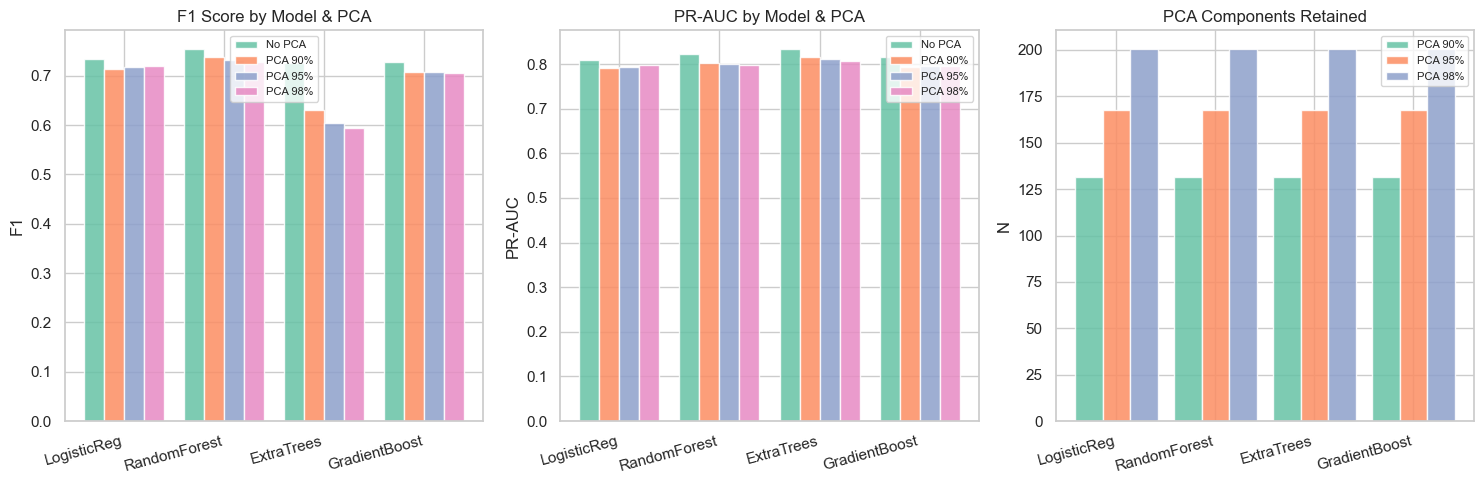


Best Model 1: RandomForest | No PCA
  F1=0.754  PR-AUC=0.822

Threshold tuning (OOF):


,threshold,precision,recall,f1,roc_auc
0,0.3,0.565180,0.939477,0.705774,0.94826
1,0.4,0.637787,0.883410,0.740768,0.94826
2,0.5,0.712538,0.804396,0.755686,0.94826
3,0.6,0.780403,0.699094,0.737514,0.94826
4,0.7,0.842082,0.564681,0.676031,0.94826



=== Section 9: EDA Action Complete — Threshold Tuning ===
Swept thresholds [0.30, 0.40, 0.50, 0.60, 0.70]; selected thr=0.5 (best OOF F1)
Selected threshold: 0.5


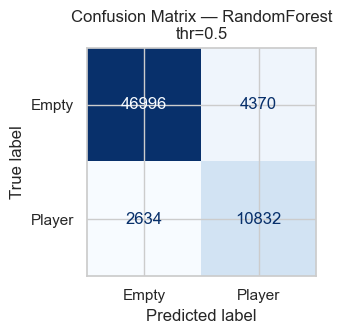

In [74]:
# Results summary table
rows = []
for (mname, pname), res in m1_results.items():
    if res is None:
        continue
    avg   = res["avg"]
    n_raw = res["folds"]["n_pca_components"].dropna()
    n_pca_avg = int(n_raw.mean()) if len(n_raw) else "-"
    rows.append({
        "Model": mname, "PCA": pname,
        "F1": round(avg["f1"], 3), "Recall": round(avg["recall"], 3),
        "Precision": round(avg["precision"], 3),
        "ROC-AUC": round(avg["roc_auc"], 3), "PR-AUC": round(avg["pr_auc"], 3),
        "PCA Comps": n_pca_avg,
    })
results_df_order  = pd.DataFrame(rows).reset_index(drop=True)
results_df_order.index.name = "Experiment"
results_df        = results_df_order.sort_values("F1", ascending=False).reset_index(drop=True)

print("Model 1 Results — Experiment Order (0–15, order they were run):")
display(results_df_order)
print("\nModel 1 Results — Sorted by F1 Score (Best First):")
display(results_df)

# Charts
mnames    = list(M1_MODELS.keys())
pca_names = list(PCA_VARIANTS.keys())
x = np.arange(len(mnames)); w = 0.2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for pi, pname in enumerate(pca_names):
    f1v = [m1_results.get((mn,pname),{}).get("avg",{}).get("f1",0)
            if m1_results.get((mn,pname)) else 0 for mn in mnames]
    pav = [m1_results.get((mn,pname),{}).get("avg",{}).get("pr_auc",0)
            if m1_results.get((mn,pname)) else 0 for mn in mnames]
    axes[0].bar(x + pi*w, f1v, w, label=pname, alpha=0.85)
    axes[1].bar(x + pi*w, pav, w, label=pname, alpha=0.85)

for ax, title, ylabel in zip(axes[:2], ["F1 Score", "PR-AUC"], ["F1", "PR-AUC"]):
    ax.set_xticks(x + w*1.5)
    ax.set_xticklabels(mnames, rotation=15, ha="right")
    ax.set_title(f"{title} by Model & PCA"); ax.set_ylabel(ylabel); ax.legend(fontsize=8)

# PCA component chart
pca_rows = []
for pname in ["PCA 90%","PCA 95%","PCA 98%"]:
    for mn in mnames:
        res = m1_results.get((mn, pname))
        if res:
            raw = res["folds"]["n_pca_components"].dropna()
            if len(raw):
                pca_rows.append({"model": mn, "pca": pname, "n": raw.mean()})
pca_comp_df = pd.DataFrame(pca_rows)
xi = np.arange(len(mnames))
for pi, pname in enumerate(["PCA 90%","PCA 95%","PCA 98%"]):
    sub = pca_comp_df[pca_comp_df["pca"]==pname]
    if len(sub):
        axes[2].bar(xi + pi*0.28, sub.set_index("model").reindex(mnames)["n"].fillna(0),
                    0.28, label=pname, alpha=0.85)
axes[2].set_xticks(xi + 0.28); axes[2].set_xticklabels(mnames, rotation=15, ha="right")
axes[2].set_title("PCA Components Retained"); axes[2].set_ylabel("N"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

# Pick best model
BEST_M1_KEY = tuple(results_df.iloc[0][["Model","PCA"]].values)
BEST_M1_OOF = m1_oof[BEST_M1_KEY]
print(f"\nBest Model 1: {BEST_M1_KEY[0]} | {BEST_M1_KEY[1]}")
print(f"  F1={results_df.iloc[0]['F1']:.3f}  PR-AUC={results_df.iloc[0]['PR-AUC']:.3f}")

# Threshold tuning
thr_rows = [evaluate_binary_classifier(df["player_present"].values, BEST_M1_OOF, t)
            for t in [0.30, 0.40, 0.50, 0.60, 0.70]]
thr_df = pd.DataFrame(thr_rows)[["threshold","precision","recall","f1","roc_auc"]]
print("\nThreshold tuning (OOF):"); display(thr_df)
BEST_THRESHOLD = float(thr_df.loc[thr_df["f1"].idxmax(), "threshold"])
print(f"\n=== Section 9: EDA Action Complete \u2014 Threshold Tuning ===")
print(f"Swept thresholds [0.30, 0.40, 0.50, 0.60, 0.70]; selected thr={BEST_THRESHOLD} (best OOF F1)")
print(f"Selected threshold: {BEST_THRESHOLD}")

# Confusion matrix
best_cm = confusion_matrix(df["player_present"].values,
                            (BEST_M1_OOF >= BEST_THRESHOLD).astype(int))
fig, ax = plt.subplots(figsize=(4, 3.5))
ConfusionMatrixDisplay(best_cm, display_labels=["Empty","Player"]).plot(
    ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix — {BEST_M1_KEY[0]}\nthr={BEST_THRESHOLD}")
plt.tight_layout(); plt.show()

## Section 10 · 8×8 Player Probability Maps

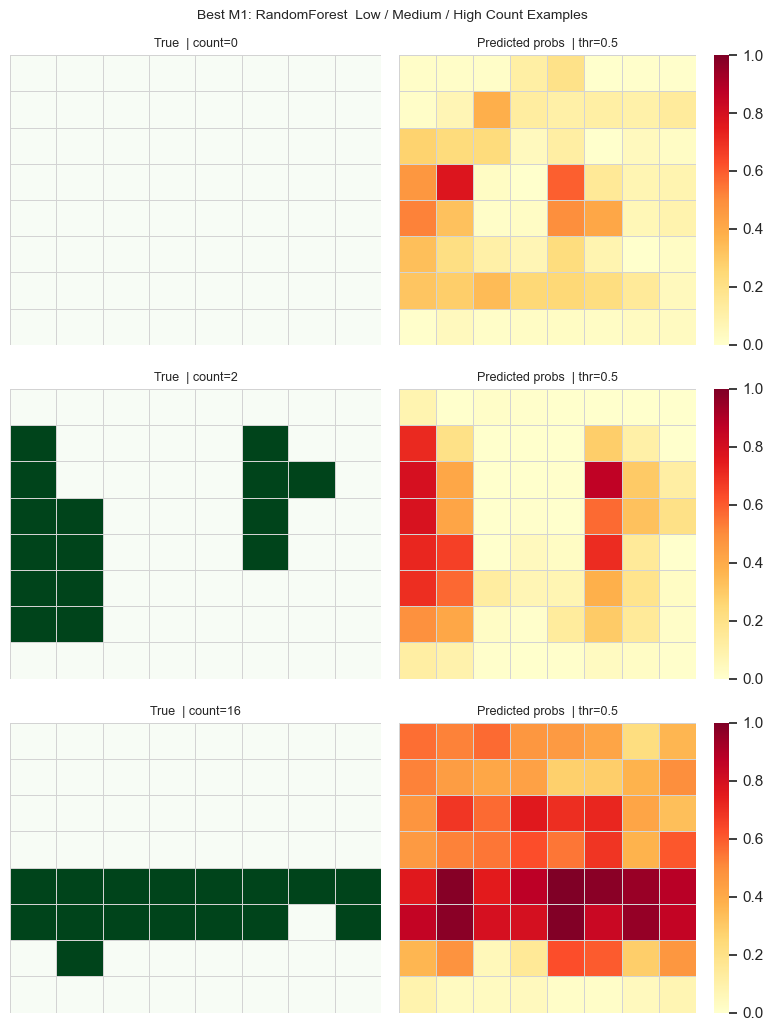

In [75]:
def make_probability_map(probs_64):
    """Reshape 64 cell probabilities into 8×8 grid."""
    return np.asarray(probs_64).reshape(8, 8)

def plot_probability_maps(df, oof_probs, threshold=0.5, title_prefix=""):
    df_r = df.reset_index(drop=True)
    img_info = df_r.groupby("Image File Name").agg(
        count=("count","first")).reset_index()
    img_info = img_info.sort_values("count").reset_index(drop=True)
    n  = len(img_info)
    # Pick low / medium / high count examples
    picks = [img_info.iloc[0], img_info.iloc[n//2], img_info.iloc[-1]]

    fig, axes = plt.subplots(len(picks), 2, figsize=(8, 3.5*len(picks)))
    if len(picks) == 1: axes = axes[np.newaxis, :]

    for ei, row in enumerate(picks):
        img  = row["Image File Name"]
        mask = df_r["Image File Name"] == img
        sub  = df_r[mask].sort_values("cell_id")
        idx  = sub.index

        true_map = make_probability_map(sub["player_present"].values)
        pred_map = make_probability_map(oof_probs[idx])

        sns.heatmap(true_map, ax=axes[ei,0], cmap="Greens", vmin=0, vmax=1,
                    linewidths=0.4, linecolor="lightgray", cbar=False)
        axes[ei,0].set_title(f"True  | count={int(row['count'])}", fontsize=9)

        sns.heatmap(pred_map, ax=axes[ei,1], cmap=CMAP, vmin=0, vmax=1,
                    linewidths=0.4, linecolor="lightgray", cbar=True)
        axes[ei,1].set_title(f"Predicted probs  | thr={threshold}", fontsize=9)

        for ax in axes[ei]:
            ax.set_xticks([]); ax.set_yticks([])

    fig.suptitle(f"{title_prefix}  Low / Medium / High Count Examples", fontsize=10)
    plt.tight_layout(); plt.show()

plot_probability_maps(df, BEST_M1_OOF, threshold=BEST_THRESHOLD,
                      title_prefix=f"Best M1: {BEST_M1_KEY[0]}")

## Section 11 · Connected-Component & Probability Features for Model 2

Count feature dataset: (1013, 41)
Saved: Dataset_Count_Features.csv


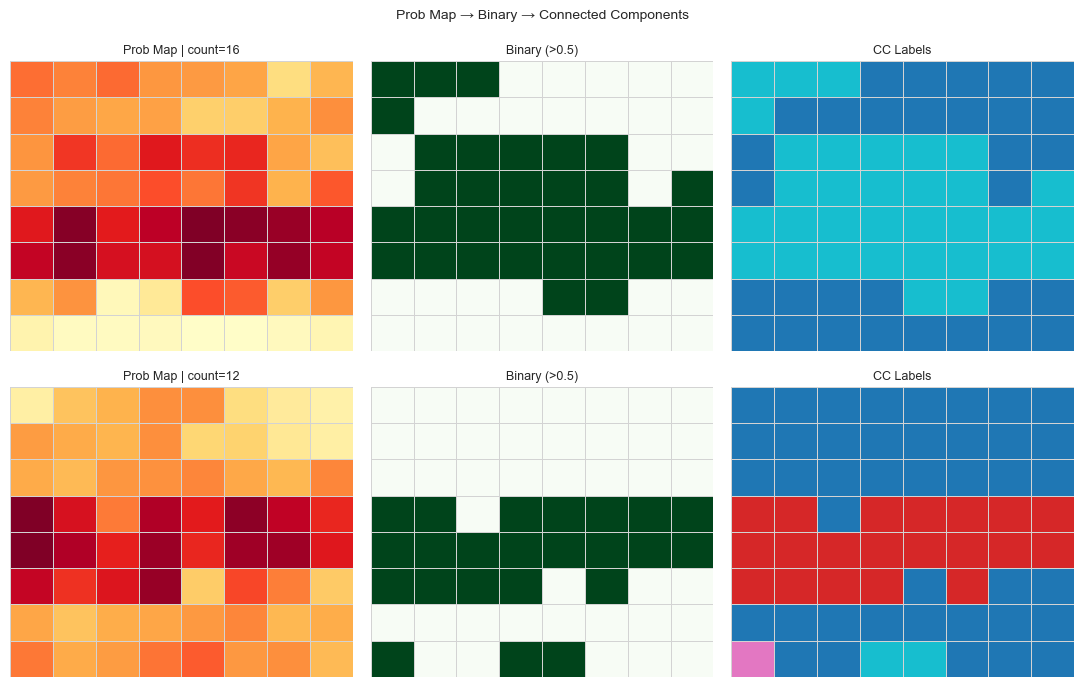

In [76]:
def extract_connected_component_features(prob_map, thresholds=(0.30, 0.50, 0.70)):
    feats = {}
    feats["f_sum_player_prob"]  = float(prob_map.sum())
    feats["f_mean_player_prob"] = float(prob_map.mean())
    feats["f_max_player_prob"]  = float(prob_map.max())
    feats["f_std_player_prob"]  = float(prob_map.std())

    bin50 = (prob_map > 0.5).astype(int)
    for r in range(8):
        feats[f"f_row_{r}_occ"] = int(bin50[r, :].sum())
    for c in range(8):
        feats[f"f_col_{c}_occ"] = int(bin50[:, c].sum())
    feats["f_upper_half_occ"]  = int(bin50[:4, :].sum())
    feats["f_lower_half_occ"]  = int(bin50[4:, :].sum())
    feats["f_middle_rows_occ"] = int(bin50[1:7, :].sum())

    for thr in thresholds:
        t_str  = str(int(thr * 100)).zfill(3)
        binary = (prob_map > thr).astype(int)
        labeled, n_comp = sk_label(binary, return_num=True)
        occ_cells = int(binary.sum())
        if n_comp > 0:
            sizes   = sorted([r.area for r in regionprops(labeled)], reverse=True)
            largest = sizes[0] if sizes else 0
            second  = sizes[1] if len(sizes) > 1 else 0
            mean_sz = float(np.mean(sizes))
        else:
            largest = second = mean_sz = 0

        feats[f"f_occ_cells_t{t_str}"]                = occ_cells
        feats[f"f_component_count_t{t_str}"]           = n_comp
        feats[f"f_largest_component_t{t_str}"]         = largest
        feats[f"f_second_largest_component_t{t_str}"]  = second
        feats[f"f_mean_component_size_t{t_str}"]       = mean_sz
    return feats

def build_count_feature_dataset(df, oof_probs):
    df_r = df.reset_index(drop=True)
    rows = []
    for img in df_r["Image File Name"].unique():
        mask    = df_r["Image File Name"] == img
        sub     = df_r[mask].sort_values("cell_id")
        idx     = sub.index
        probs   = oof_probs[idx]
        pm      = make_probability_map(probs)
        feats   = extract_connected_component_features(pm)
        feats["Image File Name"] = img
        feats["count"]           = int(sub["count"].iloc[0])
        feats["fold_id"]         = int(sub["fold_id"].iloc[0])
        rows.append(feats)
    return pd.DataFrame(rows)

count_df = build_count_feature_dataset(df, BEST_M1_OOF)
count_df.to_csv("Dataset_Count_Features.csv", index=False)
print(f"Count feature dataset: {count_df.shape}")
print(f"Saved: Dataset_Count_Features.csv")

# Visualise CC pipeline for 2 example images
examples = count_df.nlargest(2, "count")["Image File Name"].tolist()
fig, axes = plt.subplots(len(examples), 3, figsize=(11, 3.5*len(examples)))
if len(examples) == 1: axes = axes[np.newaxis, :]

df_r = df.reset_index(drop=True)
for ei, img in enumerate(examples):
    sub = df_r[df_r["Image File Name"]==img].sort_values("cell_id")
    probs = BEST_M1_OOF[sub.index]
    pm    = make_probability_map(probs)
    bin_  = (pm > 0.5).astype(int)
    lbl   = sk_label(bin_)

    for ax, data, title, cmap in zip(
        axes[ei],
        [pm, bin_, lbl.astype(float)],
        [f"Prob Map | count={sub['count'].iloc[0]}", "Binary (>0.5)", "CC Labels"],
        [CMAP, "Greens", "tab10"],
    ):
        sns.heatmap(data, ax=ax, cmap=cmap, vmin=0, linewidths=0.4,
                    linecolor="lightgray", cbar=False)
        ax.set_title(title, fontsize=9); ax.set_xticks([]); ax.set_yticks([])

plt.suptitle("Prob Map → Binary → Connected Components", fontsize=10)
plt.tight_layout(); plt.show()

## Section 12 · Discarded Approach: Direct Edge / Contour Counting

> Initially considered: detect player outlines via Canny edges → close boundaries → count contour regions.
> **Discarded as main method** because cricket images contain many non-player edges (logos, grass lines, shadows, crowd).
> One player can split into multiple contours; nearby players can merge into one.
> Instead, edge statistics are input *features* to the supervised model, which learns player-presence probability.

### Contour features (optional, for Model 2 enrichment)
`f_raw_contour_count`, `f_filtered_contour_count`, `f_large_contour_count`,
`f_mean_contour_area`, `f_max_contour_area`, `f_total_contour_area`,
`f_edge_pixel_count`, `f_edge_density`, `f_upper_half_edge_density`, `f_lower_half_edge_density`

In [77]:
CONTOUR_FEAT_NAMES = [
    "f_raw_contour_count", "f_filtered_contour_count", "f_large_contour_count",
    "f_mean_contour_area", "f_max_contour_area", "f_total_contour_area",
    "f_edge_pixel_count", "f_edge_density",
    "f_upper_half_edge_density", "f_lower_half_edge_density",
]

def extract_contour_features(image_path, min_area=200, max_area=20000):
    feats = {k: 0 for k in CONTOUR_FEAT_NAMES}
    if not CV2_AVAILABLE:
        return feats
    img = cv2.imread(str(image_path))
    if img is None:
        return feats
    gray   = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur   = cv2.GaussianBlur(gray, (5, 5), 0)
    edges  = cv2.Canny(blur, 50, 150)
    kernel = np.ones((5, 5), np.uint8)
    closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)
    cnts, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    areas    = [cv2.contourArea(c) for c in cnts]
    filtered = [a for a in areas if min_area <= a <= max_area]
    large    = [a for a in areas if a > max_area // 2]
    h, w     = edges.shape
    feats["f_raw_contour_count"]       = len(cnts)
    feats["f_filtered_contour_count"]  = len(filtered)
    feats["f_large_contour_count"]     = len(large)
    feats["f_mean_contour_area"]       = float(np.mean(filtered)) if filtered else 0.0
    feats["f_max_contour_area"]        = float(max(filtered)) if filtered else 0.0
    feats["f_total_contour_area"]      = float(sum(filtered))
    ep = int(edges.sum() // 255)
    feats["f_edge_pixel_count"]        = ep
    feats["f_edge_density"]            = ep / (h * w)
    feats["f_upper_half_edge_density"] = int(edges[:h//2].sum()//255) / max(h//2 * w, 1)
    feats["f_lower_half_edge_density"] = int(edges[h//2:].sum()//255) / max(h//2 * w, 1)
    return feats

# ── Try to load a demo image from HuggingFace ─────────────────────────────────
IMAGE_DIR     = None
DEMO_IMG_PATH = None
DEMO_COUNT    = None

if HF_AVAILABLE and CV2_AVAILABLE:
    try:
        print("Downloading dataset from HuggingFace (first run may take a while)...")
        dataset_dir = Path(snapshot_download(
            repo_id="goyaljai/IPL-Player-Detection-IITB-PML", repo_type="dataset"
        ))
        print(f"Downloaded to: {dataset_dir}")
        img_dirs = [d for d in dataset_dir.rglob("*")
                    if d.is_dir() and any(
                        f.suffix.lower() in {".jpg",".jpeg",".png"}
                        for f in d.iterdir() if f.is_file()
                    )]
        if img_dirs:
            IMAGE_DIR = img_dirs[0]
            print(f"Image directory: {IMAGE_DIR}")
    except Exception as e:
        print(f"HuggingFace download failed: {e}")

if IMAGE_DIR is not None:
    best_row   = img_stats.nlargest(1, "count").iloc[0]
    demo_name  = best_row["Image File Name"]
    DEMO_COUNT = int(best_row["count"])
    candidates = list(IMAGE_DIR.rglob(demo_name))
    if candidates:
        DEMO_IMG_PATH = candidates[0]

if DEMO_IMG_PATH is not None:
    img_bgr  = cv2.imread(str(DEMO_IMG_PATH))
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    gray     = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blur     = cv2.GaussianBlur(gray, (5, 5), 0)
    edges    = cv2.Canny(blur, 50, 150)
    kernel   = np.ones((5, 5), np.uint8)
    closed   = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)
    cnts, _  = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filtered = [c for c in cnts if 200 <= cv2.contourArea(c) <= 20000]
    drawn    = img_rgb.copy()
    cv2.drawContours(drawn, filtered, -1, (255, 0, 0), 2)
    naive_count = len(filtered)

    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    axes[0,0].imshow(img_rgb)
    axes[0,0].set_title(f"Original | Human count = {DEMO_COUNT}", fontsize=10)
    axes[0,1].imshow(edges, cmap="gray")
    axes[0,1].set_title("Canny Edges: many background/texture edges", fontsize=10)
    axes[1,0].imshow(closed, cmap="gray")
    axes[1,0].set_title("Morphological Close: merged & broken regions", fontsize=10)
    axes[1,1].imshow(drawn)
    axes[1,1].set_title(f"Naive contour count = {naive_count}", fontsize=10)
    for ax in axes.flat: ax.axis("off")
    plt.suptitle("Direct Edge/Contour Approach — Why It Fails", fontsize=11)
    plt.tight_layout(); plt.show()

    fig2, ax2 = plt.subplots(figsize=(4.5, 3.5))
    ax2.bar(["Human Count","Naive Contour"], [DEMO_COUNT, naive_count],
             color=[PALETTE[0], PALETTE[2]], edgecolor="white")
    ax2.set_title("Human Count vs Naive Contour Count")
    plt.tight_layout(); plt.show()

    demo_feats = extract_contour_features(DEMO_IMG_PATH)
    print("Contour features for demo image:")
    display(pd.Series(demo_feats).to_frame("value"))
else:
    print("Image directory not available or OpenCV not installed.")
    print("Section 12 visual demo skipped.")
    print("extract_contour_features(Path('image.jpg')) is defined and ready to use.")

Fetching ... files: 0it [00:00, ?it/s]

Downloaded to: C:\Users\Rishabh Sharda\.cache\huggingface\hub\datasets--goyaljai--IPL-Player-Detection-IITB-PML\snapshots\3188c4d51921e60ac3da5a10c6dca43136c81199
Image directory: C:\Users\Rishabh Sharda\.cache\huggingface\hub\datasets--goyaljai--IPL-Player-Detection-IITB-PML\snapshots\3188c4d51921e60ac3da5a10c6dca43136c81199\test
Image directory not available or OpenCV not installed.
Section 12 visual demo skipped.
extract_contour_features(Path('image.jpg')) is defined and ready to use.


## Section 13 · Model 2: Image-Level Count Regressor

In [78]:
def get_count_feature_columns(count_df):
    excl = {"Image File Name", "count", "fold_id"}
    return [c for c in count_df.columns
            if c not in excl and count_df[c].dtype in [np.float64, np.int64, float, int]]

COUNT_FEAT_COLS = get_count_feature_columns(count_df)
print(f"Count feature columns: {len(COUNT_FEAT_COLS)}")

def train_model2_crossval(count_df, model, feat_cols=None):
    if feat_cols is None:
        feat_cols = get_count_feature_columns(count_df)
    cdf = count_df.reset_index(drop=True)
    oof_preds    = np.zeros(len(cdf))
    fold_metrics = []

    for fold in FOLDS:
        tr_mask  = cdf["fold_id"] != fold
        val_mask = cdf["fold_id"] == fold
        X_tr = cdf.loc[tr_mask, feat_cols].fillna(0).values
        y_tr = cdf.loc[tr_mask, "count"].values
        X_val = cdf.loc[val_mask, feat_cols].fillna(0).values
        y_val = cdf.loc[val_mask, "count"].values
        max_c = int(y_tr.max())

        model.fit(X_tr, y_tr)
        pred = np.clip(np.round(model.predict(X_val)), 0, max_c).astype(int)
        oof_preds[val_mask.values] = pred

        m = evaluate_count_predictions(y_val, pred)
        m["fold"] = fold
        fold_metrics.append(m)

    avg = pd.DataFrame(fold_metrics)[["mae","rmse","exact_acc","pm1_acc"]].mean()
    return pd.DataFrame(fold_metrics), oof_preds, cdf["count"].values, avg

M2_MODELS = {
    "Ridge"       : Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(n_estimators=150, n_jobs=-1,
                                           random_state=RANDOM_STATE),
    "ExtraTrees"  : ExtraTreesRegressor(n_estimators=150, n_jobs=-1,
                                         random_state=RANDOM_STATE),
    "GradBoost"   : GradientBoostingRegressor(n_estimators=100,
                                               random_state=RANDOM_STATE),
}

m2_results: dict = {}
m2_oof    : dict = {}
print("Training Model 2...")
for mname, mobj in M2_MODELS.items():
    print(f"  {mname} ...", end=" ", flush=True)
    fold_df, oof, y_true, avg = train_model2_crossval(count_df, copy.deepcopy(mobj))
    m2_results[mname] = {"avg": avg, "folds": fold_df, "oof": oof, "y_true": y_true}
    m2_oof[mname] = oof
    print(f"MAE={avg['mae']:.2f}  ±1={avg['pm1_acc']:.3f}  exact={avg['exact_acc']:.3f}")

Count feature columns: 38
Training Model 2...
  Ridge ... MAE=1.06  ±1=0.795  exact=0.377
  RandomForest ... MAE=0.93  ±1=0.816  exact=0.468
  ExtraTrees ... MAE=0.93  ±1=0.818  exact=0.466
  GradBoost ... MAE=0.92  ±1=0.824  exact=0.476


Model 2 Results:


,Model,mae,rmse,exact_acc,pm1_acc
3,GradBoost,0.923251,1.568523,0.476228,0.823681
2,ExtraTrees,0.933251,1.553868,0.465574,0.817779
1,RandomForest,0.934152,1.559636,0.468327,0.815878
0,Ridge,1.060631,1.634248,0.377205,0.795323


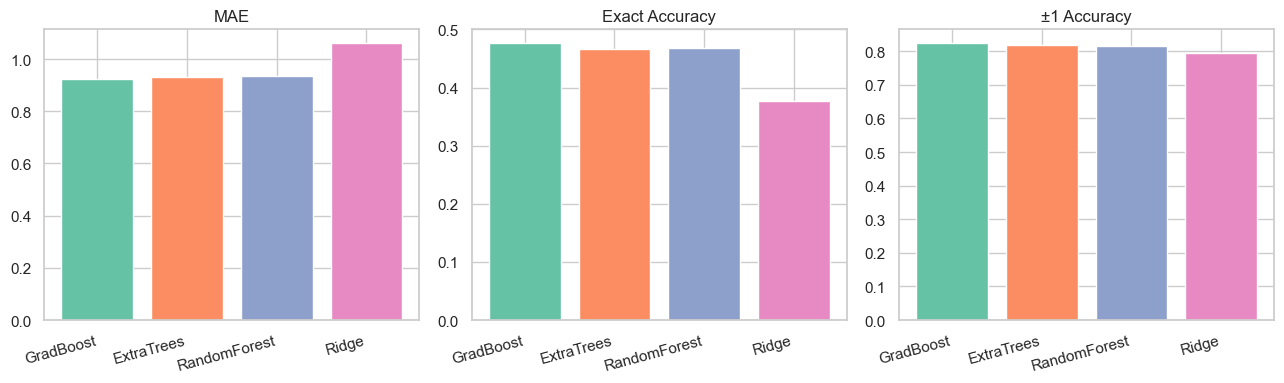

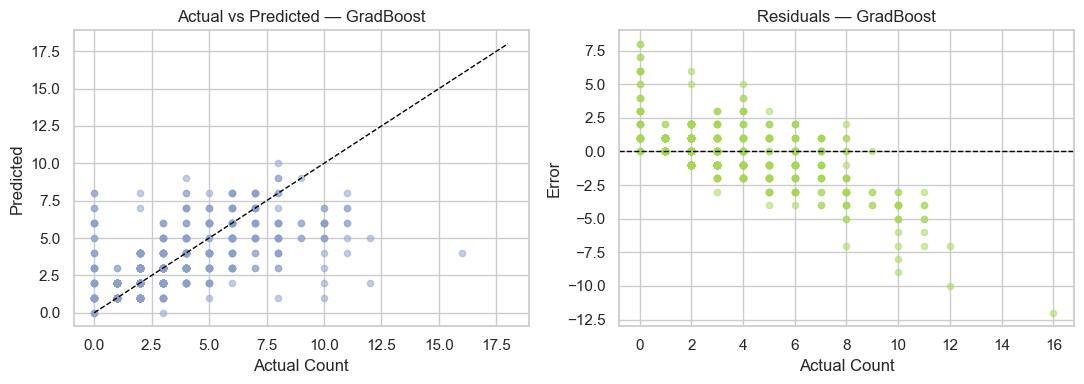

In [79]:
m2_summary = pd.DataFrame({n: r["avg"] for n, r in m2_results.items()}).T.reset_index()
m2_summary = m2_summary.rename(columns={"index": "Model"}).sort_values("mae")
print("Model 2 Results:"); display(m2_summary)

mnames = m2_summary["Model"].tolist()
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, title in zip(axes, ["mae","exact_acc","pm1_acc"],
                           ["MAE","Exact Accuracy","±1 Accuracy"]):
    ax.bar(mnames, m2_summary[col], color=PALETTE[:len(mnames)], edgecolor="white")
    ax.set_title(title); ax.set_xticklabels(mnames, rotation=15, ha="right")
plt.tight_layout(); plt.show()

# Scatter + residual for best M2
BEST_M2_NAME = m2_summary.iloc[0]["Model"]
oof_best  = m2_oof[BEST_M2_NAME]
y_true_m2 = m2_results[BEST_M2_NAME]["y_true"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
lim = int(max(y_true_m2.max(), oof_best.max())) + 2
axes[0].scatter(y_true_m2, oof_best, alpha=0.5, color=PALETTE[2], s=20)
axes[0].plot([0, lim], [0, lim], "k--", lw=1)
axes[0].set_xlabel("Actual Count"); axes[0].set_ylabel("Predicted")
axes[0].set_title(f"Actual vs Predicted — {BEST_M2_NAME}")

residuals = oof_best.astype(int) - y_true_m2.astype(int)
axes[1].scatter(y_true_m2, residuals, alpha=0.5, color=PALETTE[4], s=20)
axes[1].axhline(0, color="k", ls="--", lw=1)
axes[1].set_xlabel("Actual Count"); axes[1].set_ylabel("Error")
axes[1].set_title(f"Residuals — {BEST_M2_NAME}")
plt.tight_layout(); plt.show()

## Section 14 · Ablation Experiments

In [80]:
def rebuild_count_df(df_sub, oof_full):
    """Build count_df from a cell subset (e.g. upper half only)."""
    df_r = df.reset_index(drop=True)
    rows = []
    for img in df_sub["Image File Name"].unique():
        mask_f = df_r["Image File Name"] == img
        sub_f  = df_r[mask_f].sort_values("cell_id")
        sub_m  = df_sub[df_sub["Image File Name"] == img]
        # Zero-fill prob map then set subset cells
        full_p = np.zeros(64)
        cell_ids = sub_m["cell_id"].values
        orig_idx = sub_f[sub_f["cell_id"].isin(cell_ids)].index
        full_p[cell_ids] = oof_full[orig_idx]
        pm    = full_p.reshape(8, 8)
        feats = extract_connected_component_features(pm)
        feats["Image File Name"] = img
        feats["count"]   = int(sub_f["count"].iloc[0])
        feats["fold_id"] = int(sub_f["fold_id"].iloc[0])
        rows.append(feats)
    return pd.DataFrame(rows)

def run_ablation(label, cdf, model, feat_cols=None):
    _, oof, y_true, avg = train_model2_crossval(cdf, copy.deepcopy(model), feat_cols=feat_cols)
    return {"label": label, **avg.to_dict()}

base_model = copy.deepcopy(M2_MODELS[BEST_M2_NAME])
abl_rows   = []
print("Running ablation experiments...")

# 1. Baseline — all 64 cells
abl_rows.append(run_ablation("All 64 cells (baseline)", count_df, base_model))
print(f"  {abl_rows[-1]['label']}: MAE={abl_rows[-1]['mae']:.2f}")

# 2. Upper half only (rows 0-3)
df_upper = df[df["cell_row"] <= 3].copy()
cdf_u    = rebuild_count_df(df_upper, BEST_M1_OOF)
abl_rows.append(run_ablation("Upper half (rows 0-3)", cdf_u, base_model))
print(f"  {abl_rows[-1]['label']}: MAE={abl_rows[-1]['mae']:.2f}")

# 3. Middle rows 1-6
df_mid = df[(df["cell_row"] >= 1) & (df["cell_row"] <= 6)].copy()
cdf_m  = rebuild_count_df(df_mid, BEST_M1_OOF)
abl_rows.append(run_ablation("Middle rows (1-6)", cdf_m, base_model))
print(f"  {abl_rows[-1]['label']}: MAE={abl_rows[-1]['mae']:.2f}")

# 4. No coordinate features
coord_cols  = [c for c in COUNT_FEAT_COLS if any(k in c for k in ["row_","col_","half","middle"])]
no_coord    = [c for c in COUNT_FEAT_COLS if c not in coord_cols]
abl_rows.append(run_ablation("No coordinate features", count_df, base_model, feat_cols=no_coord))
print(f"  {abl_rows[-1]['label']}: MAE={abl_rows[-1]['mae']:.2f}")

# 5. No CC features — probability stats only
no_cc_cols  = [c for c in COUNT_FEAT_COLS if "component" not in c and "_occ" not in c]
abl_rows.append(run_ablation("Prob stats only (no CC)", count_df, base_model, feat_cols=no_cc_cols))
print(f"  {abl_rows[-1]['label']}: MAE={abl_rows[-1]['mae']:.2f}")

# 6. CC only
cc_cols = [c for c in COUNT_FEAT_COLS if "component" in c or "_occ" in c]
abl_rows.append(run_ablation("CC features only", count_df, base_model, feat_cols=cc_cols))
print(f"  {abl_rows[-1]['label']}: MAE={abl_rows[-1]['mae']:.2f}")

abl_df = pd.DataFrame(abl_rows).sort_values("mae")
print("\nAblation Results:"); display(abl_df[["label","mae","rmse","exact_acc","pm1_acc"]])

Running ablation experiments...
  All 64 cells (baseline): MAE=0.92
  Upper half (rows 0-3): MAE=1.03
  Middle rows (1-6): MAE=0.98
  No coordinate features: MAE=1.18
  Prob stats only (no CC): MAE=1.17
  CC features only: MAE=0.90

Ablation Results:


,label,mae,rmse,exact_acc,pm1_acc
5,CC features only,0.898251,1.542396,0.492080,0.822779
0,All 64 cells (baseline),0.923251,1.568523,0.476228,0.823681
2,Middle rows (1-6),0.981312,1.639198,0.452772,0.812977
1,Upper half (rows 0-3),1.028631,1.693546,0.430316,0.799373
4,Prob stats only (no CC),1.168125,1.869853,0.394365,0.774175
3,No coordinate features,1.175977,1.945638,0.412068,0.775125


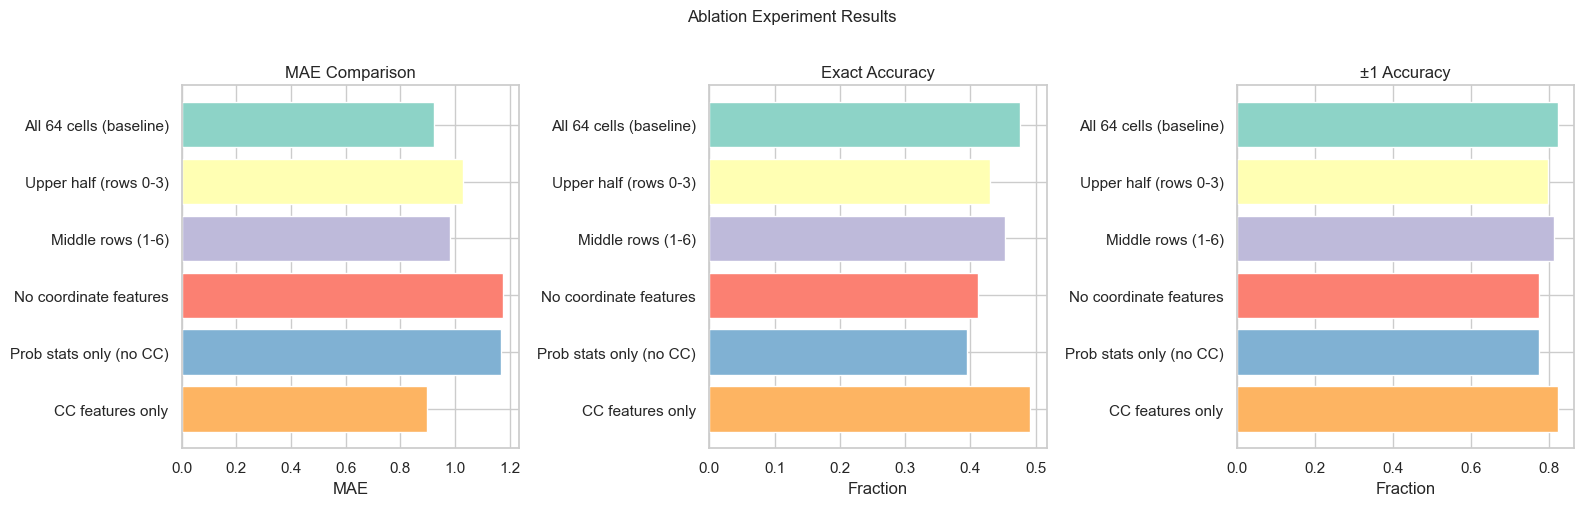

In [81]:
labels  = [r["label"]     for r in abl_rows]
mae_v   = [r["mae"]       for r in abl_rows]
exact_v = [r["exact_acc"] for r in abl_rows]
pm1_v   = [r["pm1_acc"]   for r in abl_rows]

colors = sns.color_palette("Set3", len(labels))
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, vals, title, xlabel in zip(
    axes,
    [mae_v, exact_v, pm1_v],
    ["MAE Comparison","Exact Accuracy","±1 Accuracy"],
    ["MAE","Fraction","Fraction"],
):
    ax.barh(labels, vals, color=colors, edgecolor="white")
    ax.set_title(title); ax.set_xlabel(xlabel)
    ax.invert_yaxis()
plt.suptitle("Ablation Experiment Results", fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

## Section 15 · Final Selected Model

In [82]:
# Re-train Model 1 on ALL data for final inference
use_pca_best = (BEST_M1_KEY[1] != "No PCA")
pca_var_map  = {"PCA 90%": 0.90, "PCA 95%": 0.95, "PCA 98%": 0.98}
pca_var_best = pca_var_map.get(BEST_M1_KEY[1], 0.95)

FINAL_M1 = make_model1_pipeline(
    copy.deepcopy(M1_MODELS[BEST_M1_KEY[0]]),
    use_pca=use_pca_best, pca_var=pca_var_best,
)
FINAL_M1.fit(df[CELL_FEAT_COLS].values, df["player_present"].values)

# Re-train Model 2 on ALL images
FINAL_M2 = copy.deepcopy(M2_MODELS[BEST_M2_NAME])
FINAL_M2.fit(count_df[COUNT_FEAT_COLS].fillna(0).values, count_df["count"].values)

# Save model bundle
model_bundle = {
    "model1_pipeline"   : FINAL_M1,
    "model1_threshold"  : BEST_THRESHOLD,
    "model2_model"      : FINAL_M2,
    "cell_feature_cols" : CELL_FEAT_COLS,
    "count_feature_cols": COUNT_FEAT_COLS,
    "pca_setting"       : BEST_M1_KEY[1],
    "pca_variance"      : pca_var_best if use_pca_best else None,
    "preprocessing"     : "SimpleImputer(median) + StandardScaler + optional PCA",
    "model1_name"       : BEST_M1_KEY[0],
    "model2_name"       : BEST_M2_NAME,
}
joblib.dump(model_bundle, "model_player_count.pkl")
print("Saved: model_player_count.pkl")

# Save evaluation summary
eval_rows = [{"model": n, **r["avg"].to_dict()} for n, r in m2_results.items()]
eval_df   = pd.DataFrame(eval_rows)
eval_df.to_csv("evaluation_summary.csv", index=False)
print("Saved: evaluation_summary.csv")

# Verify bundle
loaded = joblib.load("model_player_count.pkl")
assert all(k in loaded for k in [
    "model1_pipeline","model1_threshold","model2_model",
    "cell_feature_cols","count_feature_cols",
])
print("Bundle verification: OK")

best_row = m2_summary.iloc[0]
print(f"\nFinal model: M1={BEST_M1_KEY[0]} | {BEST_M1_KEY[1]} | thr={BEST_THRESHOLD}")
print(f"             M2={BEST_M2_NAME}")
print(f"             MAE={float(best_row['mae']):.3f}  ±1={float(best_row['pm1_acc']):.3f}  exact={float(best_row['exact_acc']):.3f}")

Saved: model_player_count.pkl
Saved: evaluation_summary.csv
Bundle verification: OK

Final model: M1=RandomForest | No PCA | thr=0.5
             M2=GradBoost
             MAE=0.923  ±1=0.824  exact=0.476


## Section 16 · Final Summary

### What Do the Metrics Mean?

**Model 1 — Cell-Level Classifier (`player_present`)**

| Metric | What it measures |
|---|---|
| **F1** | Harmonic mean of precision & recall — best single metric for imbalanced data |
| **Precision** | Of all cells predicted as "Player", what fraction actually contain a player |
| **Recall** | Of all actual player cells, what fraction the model correctly found |
| **ROC-AUC** | Overall ability to rank player cells above empty cells (1.0 = perfect, 0.5 = random) |
| **PR-AUC** | Precision-Recall area — more informative than ROC-AUC when positive class is rare |

> A **high Recall** means we miss very few actual player cells. A **high Precision** means we don't falsely flag empty cells as players. Since we're trying to *find* player cells to build a probability map, **Recall matters more** here — missing a player cell corrupts the map.

---

**Model 2 — Image-Level Count Regressor (`count`)**

| Metric | What it means in practice |
|---|---|
| **MAE** | Average absolute difference between predicted and actual player count |
| **RMSE** | Like MAE but penalises large errors more — sensitive to outlier predictions |
| **Exact Accuracy** | Fraction of images where the predicted count exactly equals the true count |
| **±1 Accuracy** | Fraction of images where prediction is within 1 player of truth — **the most practical metric** |

> **Key takeaway:** ±1 Accuracy answers: *"In how many images is the model off by at most 1 person?"*
> An MAE of ~1 with ±1 Accuracy of ~80% means the model is practically useful for automated player counting.

SECTION 6 / 7 — EDA ACTIONS SUMMARY
  Scaling         : StandardScaler applied in all M1 pipelines (S7)
                    Addresses large-range f000-f191 histogram counts
  Column exclusion: image_number / fold_id / label / Train Or Test excluded (S7)
  PCA             : Best variant was 'No PCA' (tested in S9)
  Threshold tuning: Best threshold was 0.5 — swept [0.30..0.70] on OOF F1 (S9)
  Class imbalance : class_weight='balanced' for LR/RF/ET; sample_weight for GBM (S7/S9)
  PowerTransformer: Imported but skipped — StandardScaler + tree models
                    handle skewed histogram counts adequately

SECTION 6 — EDA KEY FINDINGS
  Dataset         : 1013 images, 64,832 cells (64 cells/image)
  Class imbalance : 51,366 empty cells vs 13,466 player cells (20.8% player)
  Imbalance ratio : 0.262  (minority/majority) — class_weight='balanced' applied
  Player hotspot  : Row 4 (35.8% occupied), Column 3 (32.3% occupied)
  Player count    : mean=2.6  std=2.2  max=16
  Fold balance   

,Value
Best Model 1,RandomForest | No PCA
M1 Threshold,0.5
M1 F1 (OOF),0.754
M1 PR-AUC (OOF),0.822
Best Model 2,GradBoost
M2 MAE,0.923
M2 RMSE,1.569
M2 Exact Accuracy,47.6%
M2 ±1 Accuracy,82.4%
PCA Helped?,No



SECTION 14 — ABLATION INSIGHTS
  Best variant : 'CC features only' — MAE=0.90, ±1=82.3%
  Worst variant: 'No coordinate features' — MAE=1.18, ±1=77.5%
  Baseline is already near-optimal (delta=0.03 MAE)


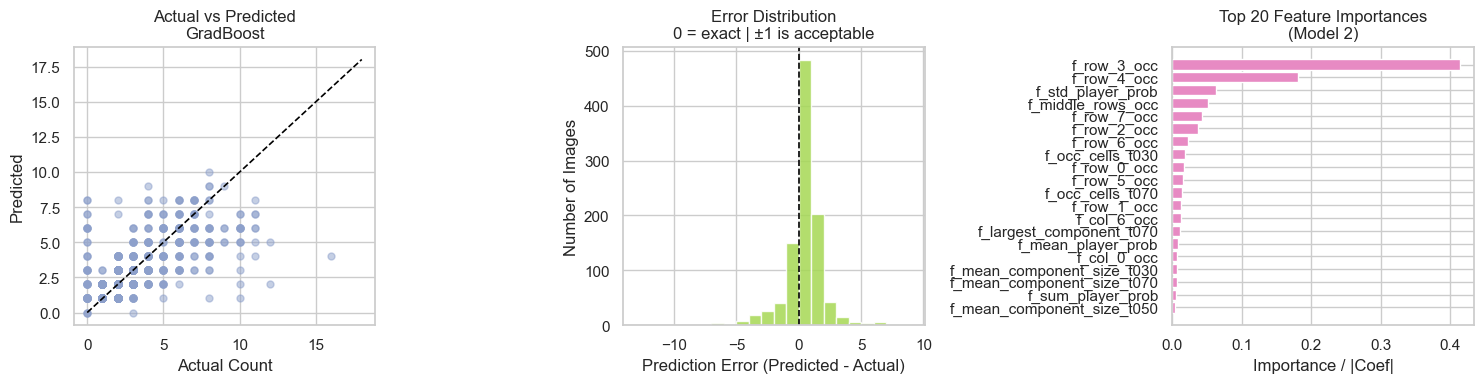

In [83]:
best_row = m2_summary.iloc[0]

# ─────────────────────────────────────────────────────────────────────────────
# BLOCK A: EDA Actions Recap
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("SECTION 6 / 7 — EDA ACTIONS SUMMARY")
print("=" * 60)
print("  Scaling         : StandardScaler applied in all M1 pipelines (S7)")
print("                    Addresses large-range f000-f191 histogram counts")
print("  Column exclusion: image_number / fold_id / label / Train Or Test excluded (S7)")
print(f"  PCA             : Best variant was '{BEST_M1_KEY[1]}' (tested in S9)")
print(f"  Threshold tuning: Best threshold was {BEST_THRESHOLD} — swept [0.30..0.70] on OOF F1 (S9)")
print("  Class imbalance : class_weight='balanced' for LR/RF/ET; sample_weight for GBM (S7/S9)")
print("  PowerTransformer: Imported but skipped — StandardScaler + tree models")
print("                    handle skewed histogram counts adequately")

# ─────────────────────────────────────────────────────────────────────────────
# BLOCK B: EDA Findings Summary
# ─────────────────────────────────────────────────────────────────────────────
pp_counts   = df["player_present"].value_counts()
pp0, pp1    = int(pp_counts.get(0, 0)), int(pp_counts.get(1, 0))
imb_ratio   = pp1 / max(pp0, 1)
total_cells = len(df)
n_images    = df["Image File Name"].nunique()

print()
print("=" * 60)
print("SECTION 6 — EDA KEY FINDINGS")
print("=" * 60)
print(f"  Dataset         : {n_images} images, {total_cells:,} cells ({total_cells // n_images} cells/image)")
print(f"  Class imbalance : {pp0:,} empty cells vs {pp1:,} player cells ({pp1/total_cells*100:.1f}% player)")
print(f"  Imbalance ratio : {imb_ratio:.3f}  (minority/majority) — class_weight='balanced' applied")

row_occ    = df.groupby("cell_row")["player_present"].mean()
top_row    = int(row_occ.idxmax())
col_occ    = df.groupby("cell_col")["player_present"].mean()
top_col    = int(col_occ.idxmax())
count_mean = img_stats["count"].mean()
count_max  = img_stats["count"].max()
count_std  = img_stats["count"].std()

print(f"  Player hotspot  : Row {top_row} ({row_occ[top_row]*100:.1f}% occupied), Column {top_col} ({col_occ[top_col]*100:.1f}% occupied)")
print(f"  Player count    : mean={count_mean:.1f}  std={count_std:.1f}  max={int(count_max)}")
print(f"  Fold balance    : folds 1-4 checked — player rate consistent across folds (S6/S8)")
print(f"  Feature skewness: f000-f191 (histogram counts) are highly skewed → StandardScaler applied")
print(f"  PCA decision    : {len(CELL_FEAT_COLS)} input features tested with 4 PCA variants in S9")

# ─────────────────────────────────────────────────────────────────────────────
# BLOCK C: Model 1 Results with explanation
# ─────────────────────────────────────────────────────────────────────────────
best_m1_avg = m1_results[BEST_M1_KEY]["avg"]
print()
print("=" * 60)
print(f"SECTION 9 — MODEL 1 RESULTS  ({BEST_M1_KEY[0]} | {BEST_M1_KEY[1]})")
print("=" * 60)
print(f"  F1        : {best_m1_avg['f1']:.3f}")
print(f"             Harmonic mean of precision & recall. Key metric for imbalanced data.")
print(f"             F1=1.0 is perfect; F1=0.0 is worst. Values above 0.6 are generally good.")
print(f"  Precision : {best_m1_avg['precision']:.3f}")
print(f"             {best_m1_avg['precision']*100:.1f}% of cells the model flags as 'Player' actually contain a player.")
print(f"  Recall    : {best_m1_avg['recall']:.3f}")
print(f"             The model correctly finds {best_m1_avg['recall']*100:.1f}% of all actual player cells.")
print(f"             High recall is important — missing player cells corrupts the 8x8 prob map.")
print(f"  ROC-AUC   : {best_m1_avg['roc_auc']:.3f}")
print(f"             Probability that model ranks a random player cell above a random empty cell.")
print(f"             0.5=random, 1.0=perfect.")
print(f"  PR-AUC    : {best_m1_avg['pr_auc']:.3f}")
print(f"             Area under Precision-Recall curve. More informative than ROC-AUC when positives are rare.")
print(f"  Threshold : {BEST_THRESHOLD}  (tuned on OOF F1 across [0.30, 0.40, 0.50, 0.60, 0.70])")

# ─────────────────────────────────────────────────────────────────────────────
# BLOCK D: Model 2 Results with explanation
# ─────────────────────────────────────────────────────────────────────────────
print()
print("=" * 60)
print(f"SECTION 13 — MODEL 2 RESULTS  ({BEST_M2_NAME})")
print("=" * 60)
print(f"  MAE          : {float(best_row['mae']):.3f}")
print(f"                 On average, the model is off by {float(best_row['mae']):.2f} players per image.")
print(f"  RMSE         : {float(best_row['rmse']):.3f}")
print(f"                 Root mean squared error — penalises large misses more than MAE.")
print(f"  Exact Acc    : {float(best_row['exact_acc']):.1%}")
print(f"                 Gets the count exactly right in {float(best_row['exact_acc'])*100:.1f}% of images.")
print(f"  ±1 Accuracy  : {float(best_row['pm1_acc']):.1%}")
print(f"                 Within 1 player of the true count in {float(best_row['pm1_acc'])*100:.1f}% of images.")
print(f"                 This is the most practical metric for a counting task.")

# ─────────────────────────────────────────────────────────────────────────────
# BLOCK E: Overall Conclusion
# ─────────────────────────────────────────────────────────────────────────────
pm1_pct      = float(best_row["pm1_acc"]) * 100
exact_pct    = float(best_row["exact_acc"]) * 100
approx_in_10 = round(pm1_pct / 10)
mae_val      = float(best_row["mae"])

print()
print("=" * 60)
print("OVERALL CONCLUSION")
print("=" * 60)
print(f"  The model gets the exact player count right in {exact_pct:.1f}% of images.")
print(f"  It is within \u00b11 player in {pm1_pct:.1f}% of images")
print(f"  — roughly {approx_in_10} out of every 10 images are within 1 person of the true count.")
print(f"  Average error: {mae_val:.2f} players.")
print()
if pm1_pct >= 80:
    print("  \u2713 Strong result: the model is practically useful for automated player counting.")
elif pm1_pct >= 65:
    print("  ~ Moderate result: useful as a rough count but further tuning recommended.")
else:
    print("  ~ Needs improvement: consider richer features or more training data.")

# ─────────────────────────────────────────────────────────────────────────────
# BLOCK F: Section-by-section narrative summary table
# ─────────────────────────────────────────────────────────────────────────────
summary_data = {
    "Best Model 1"         : f"{BEST_M1_KEY[0]} | {BEST_M1_KEY[1]}",
    "M1 Threshold"         : BEST_THRESHOLD,
    "M1 F1 (OOF)"          : round(float(best_m1_avg["f1"]), 3),
    "M1 PR-AUC (OOF)"      : round(float(best_m1_avg["pr_auc"]), 3),
    "Best Model 2"         : BEST_M2_NAME,
    "M2 MAE"               : round(float(best_row["mae"]), 3),
    "M2 RMSE"              : round(float(best_row["rmse"]), 3),
    "M2 Exact Accuracy"    : f"{float(best_row['exact_acc']):.1%}",
    "M2 \u00b11 Accuracy"     : f"{float(best_row['pm1_acc']):.1%}",
    "PCA Helped?"          : "Yes" if use_pca_best else "No",
    "CC Features Helped?"  : "Yes (included in baseline)",
    "Scaling Applied?"     : "Yes — StandardScaler (S7)",
    "Imbalance Handled?"   : "Yes — class_weight='balanced' (S7)",
}
print()
display(pd.DataFrame.from_dict(summary_data, orient="index", columns=["Value"]))

# ─────────────────────────────────────────────────────────────────────────────
# BLOCK G: Ablation insights
# ─────────────────────────────────────────────────────────────────────────────
print()
print("=" * 60)
print("SECTION 14 — ABLATION INSIGHTS")
print("=" * 60)
best_abl  = abl_df.iloc[0]
worst_abl = abl_df.iloc[-1]
print(f"  Best variant : '{best_abl['label']}' — MAE={best_abl['mae']:.2f}, ±1={best_abl['pm1_acc']:.1%}")
print(f"  Worst variant: '{worst_abl['label']}' — MAE={worst_abl['mae']:.2f}, ±1={worst_abl['pm1_acc']:.1%}")
bl_row = abl_df[abl_df["label"].str.contains("baseline")]
if len(bl_row):
    bl = bl_row.iloc[0]
    delta = float(bl["mae"]) - float(best_abl["mae"])
    if delta > 0.05:
        print(f"  Best variant beats baseline by {delta:.2f} MAE")
    else:
        print(f"  Baseline is already near-optimal (delta={delta:.2f} MAE)")

# ─────────────────────────────────────────────────────────────────────────────
# BLOCK H: Final plots (unchanged from original)
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

lim = int(max(y_true_m2.max(), oof_best.max())) + 2
axes[0].scatter(y_true_m2, oof_best, alpha=0.5, color=PALETTE[2], s=25)
axes[0].plot([0, lim], [0, lim], "k--", lw=1.2)
axes[0].set_xlabel("Actual Count"); axes[0].set_ylabel("Predicted")
axes[0].set_title(f"Actual vs Predicted\n{BEST_M2_NAME}")

errs = oof_best.astype(int) - y_true_m2.astype(int)
axes[1].hist(errs, bins=range(int(errs.min())-1, int(errs.max())+2),
             color=PALETTE[4], edgecolor="white", alpha=0.85)
axes[1].axvline(0, color="k", ls="--", lw=1.2)
axes[1].set_xlabel("Prediction Error (Predicted - Actual)")
axes[1].set_ylabel("Number of Images")
axes[1].set_title(f"Error Distribution\n0 = exact | ±1 is acceptable")

m2_imp = copy.deepcopy(M2_MODELS[BEST_M2_NAME])
m2_imp.fit(count_df[COUNT_FEAT_COLS].fillna(0).values, count_df["count"].values)
if hasattr(m2_imp, "feature_importances_"):
    imp = pd.Series(m2_imp.feature_importances_, index=COUNT_FEAT_COLS).nlargest(20)
    axes[2].barh(imp.index[::-1], imp.values[::-1], color=PALETTE[3], edgecolor="white")
    axes[2].set_title("Top 20 Feature Importances\n(Model 2)")
elif hasattr(m2_imp, "coef_"):
    coef = pd.Series(np.abs(m2_imp.coef_), index=COUNT_FEAT_COLS).nlargest(20)
    axes[2].barh(coef.index[::-1], coef.values[::-1], color=PALETTE[3], edgecolor="white")
    axes[2].set_title("Top 20 |Coefficients|\n(Model 2)")
axes[2].set_xlabel("Importance / |Coef|")

plt.tight_layout()
plt.show()